<a href="https://colab.research.google.com/github/Konzx/Quant-Finance-Projects/blob/main/NIFTY_Options_Volatility_Based_Straddle_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# pip install py_vollib
import plotly.graph_objects as go
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings(action = 'ignore')
from pathlib import Path
import duckdb
import os
import re
import glob
import math
import gc
from tqdm import tqdm
import matplotlib.pyplot as plt

In [11]:


from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Data Import**

In [12]:
spot = pd.read_parquet(r"/content/drive/Othercomputers/My Laptop/1 EPAT 2025/@ My 2025 and onwards effort/Kite_NIFTY_INDEX_2006_01_01_to_2026_01_15.parquet")
spot.set_index('Datetime', inplace = True)
spot.sort_index(inplace = True)
spot = spot['2020-01-01':'2026-05-01']
spot.tail(3)

,Open,High,Low,Close
Datetime,,,,
2026-04-30 15:27:00,24022.3,24031.8,24018.15,24027.55
2026-04-30 15:28:00,24025.5,24042.8,24024.45,24041.10
2026-04-30 15:29:00,24042.3,24051.8,24035.45,24043.70


In [13]:
spot.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 586721 entries, 2020-01-01 09:15:00 to 2026-04-30 15:29:00
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Open    586721 non-null  float64
 1   High    586721 non-null  float64
 2   Low     586721 non-null  float64
 3   Close   586721 non-null  float64
dtypes: float64(4)
memory usage: 22.4 MB


## **Tagging ATM IV to each timestamp**

In [14]:
def build_expiry_file_map(options_folder):
    """
    Scans local parquet files and extracts expiry dates from filenames.

    Expected filename examples:
        expiry_2024-01-11.parquet
        2024_01_11.parquet
        20240111.parquet

    Returns:
        expiry_map_df -> dataframe with columns:
                         ['expiry', 'filepath']
    """

    def extract_expiry_from_filename(filepath):
        fname = os.path.basename(filepath)

        patterns = [
            r'(\d{4}-\d{2}-\d{2})',  # 2024-01-11
            r'(\d{4}_\d{2}_\d{2})',  # 2024_01_11
            r'(\d{8})'               # 20240111
        ]

        for pattern in patterns:
            match = re.search(pattern, fname)
            if match:
                raw = match.group(1)

                if "-" in raw:
                    return pd.to_datetime(raw).normalize()
                elif "_" in raw:
                    return pd.to_datetime(raw.replace("_", "-")).normalize()
                else:
                    return pd.to_datetime(raw, format="%Y%m%d").normalize()

        raise ValueError(f"Could not extract expiry date from filename: {fname}")

    # Find all parquet files
    files = sorted(glob.glob(os.path.join(options_folder, "*.parquet")))

    if not files:
        raise FileNotFoundError(f"No parquet files found in folder: {options_folder}")

    rows = []
    for fp in files:
        expiry = extract_expiry_from_filename(fp)
        rows.append({
            "expiry_date": expiry,
            "filepath": fp
        })

    expiry_map_df = pd.DataFrame(rows).sort_values("expiry_date").reset_index(drop=True)

    return expiry_map_df

In [15]:
expiry_map_df = build_expiry_file_map(r"/content/drive/Othercomputers/My Laptop/1 EPAT 2025/@ My 2025 and onwards effort/Breeze Historical Data/options_data/1min_data_with_greeks2")
expiry_map_df.head()

,expiry_date,filepath
0,2020-01-02,/content/drive/Othercomputers/My Laptop/1 EPAT...
1,2020-01-09,/content/drive/Othercomputers/My Laptop/1 EPAT...
2,2020-01-16,/content/drive/Othercomputers/My Laptop/1 EPAT...
3,2020-01-23,/content/drive/Othercomputers/My Laptop/1 EPAT...
4,2020-01-30,/content/drive/Othercomputers/My Laptop/1 EPAT...


In [16]:
sample = pd.read_parquet(expiry_map_df['filepath'][0])
sample.head()

,close,datetime,exchange_code,expiry_date,high,low,open,open_interest,product_type,right,...,spot_open,spot_high,spot_low,spot_close,spot_volume,iv,delta,gamma,theta,vega
0,230.00,2019-12-03 11:18:00,NFO,02-JAN-2020,230.00,230.00,230.00,75,Options,CALL,...,12007.75,12008.85,12004.65,12004.70,0,0.142947,0.559919,0.000799,-4.291898,13.614538
1,169.00,2019-12-11 09:47:00,NFO,02-JAN-2020,169.00,169.00,169.00,750,Options,CALL,...,11893.80,11904.50,11893.75,11902.95,0,0.123641,0.556919,0.001087,-4.287063,11.601587
2,170.05,2019-12-11 09:58:00,NFO,02-JAN-2020,170.05,170.05,170.05,675,Options,CALL,...,11891.70,11893.05,11890.25,11892.20,0,0.129662,0.543680,0.001042,-4.428949,11.638242
3,173.80,2019-12-11 10:23:00,NFO,02-JAN-2020,173.80,173.80,173.80,750,Options,CALL,...,11900.10,11903.00,11900.10,11902.20,0,0.128230,0.554520,0.001050,-4.405753,11.604204
4,180.00,2019-12-11 15:10:00,NFO,02-JAN-2020,180.00,180.00,180.00,675,Options,CALL,...,11914.55,11921.15,11912.85,11921.15,0,0.125081,0.575726,0.001070,-4.356816,11.468612


In [17]:
def build_spot_atm_iv_df(
    spot_df: pd.DataFrame,
    expiry_map_df: pd.DataFrame,
    expiry_recency: str = "nearest",
    spot_datetime_col: str | None = None,
    expiry_date_col: str = "expiry_date",
    filepath_col: str = "filepath",
    option_datetime_col: str = "datetime",
    option_type_col: str = "right",
    strike_col: str = "strike",
    iv_col: str = "iv",
) -> pd.DataFrame:
    """
    Creates dataframe with:
    spot OHLC + strike-based ATM Call IV + ATM Put IV + ATM IV
    + expiry_datetime + time_to_expiration.

    ATM is selected by strike closeness:
        ATM strike = strike closest to spot Close

    If exact ATM strike is unavailable, nearest available strike is used.

    expiry_recency:
        "nearest" -> nearest available expiry >= spot timestamp
        "next"    -> second nearest available expiry >= spot timestamp
    """

    if expiry_recency not in {"nearest", "next"}:
        raise ValueError("expiry_recency must be either 'nearest' or 'next'")

    # -----------------------------
    # Prepare spot data
    # -----------------------------
    spot = spot_df.copy()
    spot = spot.sort_index()

    if spot_datetime_col is not None:
        spot["spot_datetime"] = pd.to_datetime(spot[spot_datetime_col])
    else:
        spot["spot_datetime"] = pd.to_datetime(spot.index)

    # -----------------------------
    # Prepare expiry map
    # -----------------------------
    expiry_map = expiry_map_df.copy()
    expiry_map[expiry_date_col] = pd.to_datetime(expiry_map[expiry_date_col])

    expiry_map["expiry_datetime"] = expiry_map[expiry_date_col].apply(
        lambda x: pd.Timestamp(x.date()) + pd.Timedelta(hours=15, minutes=29)
    )

    expiry_map = expiry_map.sort_values("expiry_datetime").reset_index(drop=True)

    expiries = expiry_map["expiry_datetime"].to_numpy()
    spot_times = spot["spot_datetime"].to_numpy()

    # -----------------------------
    # Find nearest / next expiry
    # -----------------------------
    idx = np.searchsorted(expiries, spot_times, side="left")

    if expiry_recency == "next":
        idx = idx + 1

    valid_mask = idx < len(expiries)

    spot = spot.loc[valid_mask].copy()
    idx = idx[valid_mask]

    spot["expiry_datetime"] = expiry_map.loc[idx, "expiry_datetime"].to_numpy()
    spot["expiry_date"] = pd.to_datetime(spot["expiry_datetime"]).dt.date

    spot["time_to_expiration"] = (
        spot["expiry_datetime"] - spot["spot_datetime"]
    ).dt.total_seconds() / (365 * 24 * 60 * 60)

    # -----------------------------
    # Read option files expiry-wise
    # -----------------------------
    all_parts = []

    for expiry_dt, group in spot.groupby("expiry_datetime"):

        file_row = expiry_map[expiry_map["expiry_datetime"] == expiry_dt]

        if file_row.empty:
            continue

        filepath = file_row.iloc[0][filepath_col]

        option_df = pd.read_parquet(filepath).copy()

        option_df[option_datetime_col] = pd.to_datetime(option_df[option_datetime_col])

        option_df[option_type_col] = (
            option_df[option_type_col]
            .astype(str)
            .str.upper()
            .str.strip()
        )

        option_df[strike_col] = pd.to_numeric(option_df[strike_col], errors="coerce")
        option_df[iv_col] = pd.to_numeric(option_df[iv_col], errors="coerce")

        option_df = option_df.dropna(subset=[option_datetime_col, strike_col, iv_col])

        calls = option_df[option_df[option_type_col].isin(["CE", "CALL", "C"])].copy()
        puts = option_df[option_df[option_type_col].isin(["PE", "PUT", "P"])].copy()

        # Keep only spot rows belonging to this expiry
        group = group.copy()

        # -----------------------------
        # Merge spot close into option rows
        # -----------------------------
        spot_for_merge = group[["spot_datetime", "Close"]].copy()

        calls = calls.merge(
            spot_for_merge,
            left_on=option_datetime_col,
            right_on="spot_datetime",
            how="inner"
        )

        puts = puts.merge(
            spot_for_merge,
            left_on=option_datetime_col,
            right_on="spot_datetime",
            how="inner"
        )

        # -----------------------------
        # Select nearest strike to spot Close
        # -----------------------------
        calls["strike_diff"] = (calls[strike_col] - calls["Close"]).abs()
        puts["strike_diff"] = (puts[strike_col] - puts["Close"]).abs()

        atm_call_iv = (
            calls.sort_values(["spot_datetime", "strike_diff"])
            .groupby("spot_datetime", as_index=False)
            .first()[["spot_datetime", strike_col, iv_col]]
            .rename(columns={
                strike_col: "atm_call_strike",
                iv_col: "atm_call_iv"
            })
        )

        atm_put_iv = (
            puts.sort_values(["spot_datetime", "strike_diff"])
            .groupby("spot_datetime", as_index=False)
            .first()[["spot_datetime", strike_col, iv_col]]
            .rename(columns={
                strike_col: "atm_put_strike",
                iv_col: "atm_put_iv"
            })
        )

        merged_iv = atm_call_iv.merge(
            atm_put_iv,
            on="spot_datetime",
            how="outer"
        )

        part = group.reset_index(drop=True).merge(
            merged_iv,
            on="spot_datetime",
            how="left"
        )

        all_parts.append(part)

    if not all_parts:
        raise ValueError("No matching option data found.")

    final_df = pd.concat(all_parts, ignore_index=True)

    final_df = final_df.sort_values("spot_datetime").set_index("spot_datetime")

    final_df = final_df[
        [
            "Open",
            "High",
            "Low",
            "Close",
            "expiry_datetime",
            "time_to_expiration",
            "atm_call_strike",
            "atm_put_strike",
            "atm_call_iv",
            "atm_put_iv",
        ]
    ]

    final_df["atm_iv"] = (
        final_df[["atm_call_iv", "atm_put_iv"]]
        .replace(0, np.nan)
        .mean(axis=1)
    )

    return final_df

In [18]:
nearest_df = build_spot_atm_iv_df(
    spot_df=spot,
    expiry_map_df=expiry_map_df,
    expiry_recency="nearest"
)

In [19]:
print(nearest_df.shape)
print(nearest_df[nearest_df['atm_iv'].isna()].shape)

(586721, 11)
(1283, 11)


In [20]:
nearest_df[nearest_df['atm_iv'].isna()].head()

,Open,High,Low,Close,expiry_datetime,time_to_expiration,atm_call_strike,atm_put_strike,atm_call_iv,atm_put_iv,atm_iv
spot_datetime,,,,,,,,,,,
2020-03-13 09:22:00,8624.05,8624.05,8624.05,8624.05,2020-03-19 15:29:00,0.017137,NaN,NaN,NaN,NaN,NaN
2020-03-13 09:23:00,8624.05,8624.05,8624.05,8624.05,2020-03-19 15:29:00,0.017135,NaN,NaN,NaN,NaN,NaN
2020-03-13 09:24:00,8624.05,8624.05,8624.05,8624.05,2020-03-19 15:29:00,0.017133,NaN,NaN,NaN,NaN,NaN
2020-03-13 09:25:00,8624.05,8624.05,8624.05,8624.05,2020-03-19 15:29:00,0.017131,NaN,NaN,NaN,NaN,NaN
2020-03-13 09:26:00,8624.05,8624.05,8624.05,8624.05,2020-03-19 15:29:00,0.017129,NaN,NaN,NaN,NaN,NaN


In [21]:
list(nearest_df[nearest_df['atm_iv'].isna()].index.normalize().unique())

[Timestamp('2020-03-13 00:00:00'),
 Timestamp('2020-03-23 00:00:00'),
 Timestamp('2020-11-14 00:00:00'),
 Timestamp('2021-01-11 00:00:00'),
 Timestamp('2021-11-04 00:00:00'),
 Timestamp('2022-01-12 00:00:00'),
 Timestamp('2022-10-24 00:00:00'),
 Timestamp('2023-03-01 00:00:00'),
 Timestamp('2023-03-13 00:00:00'),
 Timestamp('2023-05-12 00:00:00'),
 Timestamp('2023-07-27 00:00:00'),
 Timestamp('2023-11-12 00:00:00'),
 Timestamp('2024-11-01 00:00:00'),
 Timestamp('2024-12-19 00:00:00'),
 Timestamp('2025-08-06 00:00:00')]

In [22]:

list(nearest_df[nearest_df['atm_iv'].isna()]['expiry_datetime'].dt.date.unique())

[datetime.date(2020, 3, 19),
 datetime.date(2020, 3, 26),
 datetime.date(2020, 11, 19),
 datetime.date(2021, 1, 14),
 datetime.date(2021, 11, 11),
 datetime.date(2022, 1, 13),
 datetime.date(2022, 10, 27),
 datetime.date(2023, 3, 2),
 datetime.date(2023, 3, 16),
 datetime.date(2023, 5, 18),
 datetime.date(2023, 7, 27),
 datetime.date(2023, 11, 16),
 datetime.date(2024, 11, 7),
 datetime.date(2024, 12, 19),
 datetime.date(2025, 8, 7)]

In [23]:
sample = pd.read_parquet(r"/content/drive/Othercomputers/My Laptop/1 EPAT 2025/@ My 2025 and onwards effort/Breeze Historical Data/options_data/1min_data_with_greeks2/NIFTY_2020-02-06.parquet")
# print(display(sample.columns))
# display(sample.head())
# sample.info()
# sample_slice = sample[sample['datetime'].dt.date == '2020-01-08']
# sample_slice.head()


sample['datetime'] = pd.to_datetime(sample['datetime'])

# Exact date
sample[sample['datetime'].dt.date == pd.to_datetime('2020-02-01').date()]

,close,datetime,exchange_code,expiry_date,high,low,open,open_interest,product_type,right,...,index,spot_open,spot_high,spot_low,spot_close,iv,delta,gamma,theta,vega
53262,775.00,2020-02-01 10:03:00,NFO,06-FEB-2020,775.00,775.00,775.00,225,Options,CALL,...,467069,11968.30,11978.90,11968.30,11974.25,NaN,NaN,NaN,NaN,NaN
53263,746.50,2020-02-01 10:04:00,NFO,06-FEB-2020,746.50,746.50,746.50,225,Options,CALL,...,467070,11970.50,11977.60,11960.85,11969.90,NaN,NaN,NaN,NaN,NaN
53264,746.50,2020-02-01 11:03:00,NFO,06-FEB-2020,746.50,746.50,746.50,300,Options,CALL,...,467129,11978.40,11988.00,11974.90,11984.60,NaN,NaN,NaN,NaN,NaN
53265,730.00,2020-02-01 13:04:00,NFO,06-FEB-2020,730.00,730.00,730.00,375,Options,CALL,...,467250,11935.40,11941.20,11921.05,11941.20,NaN,NaN,NaN,NaN,NaN
53266,593.75,2020-02-01 13:20:00,NFO,06-FEB-2020,593.75,593.75,593.75,450,Options,CALL,...,467266,11821.60,11829.15,11818.55,11828.35,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64230,528.75,2020-02-01 15:24:00,NFO,06-FEB-2020,530.00,528.75,530.00,95325,Options,PUT,...,467390,11637.65,11642.15,11635.35,11641.25,0.322006,-0.862983,0.000500,-7.880594,2.989684
64231,521.20,2020-02-01 15:25:00,NFO,06-FEB-2020,525.00,521.20,525.00,95325,Options,PUT,...,467391,11641.15,11643.30,11635.20,11637.55,0.282448,-0.896467,0.000468,-5.121471,2.452457
64232,528.00,2020-02-01 15:26:00,NFO,06-FEB-2020,531.10,528.00,531.10,95325,Options,PUT,...,467392,11638.00,11642.40,11636.70,11641.55,0.320395,-0.864112,0.000499,-7.777944,2.972470
64233,528.00,2020-02-01 15:27:00,NFO,06-FEB-2020,530.00,528.00,530.00,91875,Options,PUT,...,467393,11641.50,11644.70,11639.35,11643.75,0.326694,-0.858186,0.000504,-8.264958,3.060516


# **Realized Volatility calculation as per time to expiration**

In [24]:
def log_returns(df):
  df = df.copy()
  df.reset_index(inplace = True)
  df['date_only'] = df['spot_datetime'].dt.date
  df['row_no'] = df.groupby('date_only').cumcount() + 1
  df['is_first_minute'] = np.where(df['row_no'] == 1, True, False)
  df.set_index('spot_datetime', inplace = True)
  df.index = pd.to_datetime(df.index)
  df = df.sort_index()


  # Calculating log returns for every minute except the first of each day to skip gap-up and gap-down jumps
  df['log_return'] = np.nan  # Initialize with NaN

  # Computing log return only if NOT the first minute of the day
  # For all other minutes, calculate log(price_t / price_{t-1})
  df['log_return'] = np.where(
      ~df['is_first_minute'],
      np.log(df['Close'] / df['Close'].shift(1)),
      np.nan
  )

  df = df[df['is_first_minute'] == False]
  return df

spot_df = log_returns(nearest_df)
spot_df.head()

,Open,High,Low,Close,expiry_datetime,time_to_expiration,atm_call_strike,atm_put_strike,atm_call_iv,atm_put_iv,atm_iv,date_only,row_no,is_first_minute,log_return
spot_datetime,,,,,,,,,,,,,,,
2020-01-01 09:16:00,12214.55,12216.15,12205.70,12206.80,2020-01-02 15:29:00,0.003449,12200.0,12200.0,0.111315,0.133203,0.122259,2020-01-01,2,False,-0.000680
2020-01-01 09:17:00,12205.20,12207.40,12203.15,12203.55,2020-01-02 15:29:00,0.003447,12200.0,12200.0,0.113769,0.128409,0.121089,2020-01-01,3,False,-0.000266
2020-01-01 09:18:00,12202.15,12208.40,12201.45,12208.35,2020-01-02 15:29:00,0.003446,12200.0,12200.0,0.112726,0.130086,0.121406,2020-01-01,4,False,0.000393
2020-01-01 09:19:00,12208.50,12213.10,12207.70,12211.30,2020-01-02 15:29:00,0.003444,12200.0,12200.0,0.112554,0.126281,0.119417,2020-01-01,5,False,0.000242
2020-01-01 09:20:00,12211.85,12212.75,12210.00,12211.35,2020-01-02 15:29:00,0.003442,12200.0,12200.0,0.111243,0.125505,0.118374,2020-01-01,6,False,0.000004


In [25]:
def realized_volatility_calculation(
    df,
    log_return_col="log_return",
    tte_col="time_to_expiration",
    minutes_per_year=252 * 375
):
    df = df.copy()

    # ensure datetime index
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    # convert TTE from years if needed
    df["tte_minutes"] = (df[tte_col] * minutes_per_year).round().astype("Int64")

    rv_values = []

    log_ret = df[log_return_col].to_numpy()
    windows = df["tte_minutes"].to_numpy()

    for i in range(len(df)):
        w = windows[i]

        if pd.isna(w) or w <= 1 or i < w:
            rv_values.append(np.nan)
            continue

        window_returns = log_ret[i - w + 1 : i + 1]

        rv = np.sqrt(np.nansum(window_returns ** 2) * (minutes_per_year / w))

        rv_values.append(rv)

    df["RV"] = rv_values

    return df

spot_df = realized_volatility_calculation(spot_df)
spot_df.head()

,Open,High,Low,Close,expiry_datetime,time_to_expiration,atm_call_strike,atm_put_strike,atm_call_iv,atm_put_iv,atm_iv,date_only,row_no,is_first_minute,log_return,tte_minutes,RV
spot_datetime,,,,,,,,,,,,,,,,,
2020-01-01 09:16:00,12214.55,12216.15,12205.70,12206.80,2020-01-02 15:29:00,0.003449,12200.0,12200.0,0.111315,0.133203,0.122259,2020-01-01,2,False,-0.000680,326,NaN
2020-01-01 09:17:00,12205.20,12207.40,12203.15,12203.55,2020-01-02 15:29:00,0.003447,12200.0,12200.0,0.113769,0.128409,0.121089,2020-01-01,3,False,-0.000266,326,NaN
2020-01-01 09:18:00,12202.15,12208.40,12201.45,12208.35,2020-01-02 15:29:00,0.003446,12200.0,12200.0,0.112726,0.130086,0.121406,2020-01-01,4,False,0.000393,326,NaN
2020-01-01 09:19:00,12208.50,12213.10,12207.70,12211.30,2020-01-02 15:29:00,0.003444,12200.0,12200.0,0.112554,0.126281,0.119417,2020-01-01,5,False,0.000242,325,NaN
2020-01-01 09:20:00,12211.85,12212.75,12210.00,12211.35,2020-01-02 15:29:00,0.003442,12200.0,12200.0,0.111243,0.125505,0.118374,2020-01-01,6,False,0.000004,325,NaN


In [26]:
def ivr_calculations(final_df):

    # IVR calculation
    intraday_window = 5 * 375
    min_obs = int(0.99 * intraday_window)

    iv_intraday_min = final_df["atm_iv"].rolling(
        intraday_window,
        min_periods=min_obs
    ).min()

    iv_intraday_max = final_df["atm_iv"].rolling(
        intraday_window,
        min_periods=min_obs
    ).max()

    final_df["iv_intraday_min"] = iv_intraday_min
    final_df["iv_intraday_max"] = iv_intraday_max

    final_df["ivr_intraday"] = (
        (final_df["atm_iv"] - iv_intraday_min) /
        (iv_intraday_max - iv_intraday_min)
    ).replace([np.inf, -np.inf], np.nan)

    # IV Percentile: % of past IV values below current IV
    final_df["iv_percentile_intraday"] = (
        final_df["atm_iv"]
        .rolling(window=intraday_window, min_periods=intraday_window)
        .apply(lambda x: (x <= x.iloc[-1]).mean(), raw=False)
    )

    # 15-minute IVR
    iv_min_15 = final_df["atm_iv"].rolling(
        window=15,
        min_periods=15
    ).min()

    iv_max_15 = final_df["atm_iv"].rolling(
        window=15,
        min_periods=15
    ).max()

    final_df["ivr_15mins"] = (
        (final_df["atm_iv"] - iv_min_15) /
        (iv_max_15 - iv_min_15)
    ).replace([np.inf, -np.inf], np.nan)

    # 15-minute IV Percentile
    final_df["iv_percentile_15mins"] = (
        final_df["atm_iv"]
        .rolling(window=15, min_periods=15)
        .apply(lambda x: (x <= x.iloc[-1]).mean(), raw=False)
    )

    return final_df

ivr_df = spot_df.copy()
ivr_df = ivr_calculations(ivr_df)

# **Creating signal_df**

In [27]:
print(ivr_df.isnull().sum())

Open                          0
High                          0
Low                           0
Close                         0
expiry_datetime               0
time_to_expiration            0
atm_call_strike            1274
atm_put_strike             1285
atm_call_iv                1274
atm_put_iv                 1285
atm_iv                     1274
date_only                     0
row_no                        0
is_first_minute               0
log_return                    0
tte_minutes                   0
RV                         3611
iv_intraday_min           21478
iv_intraday_max           21478
ivr_intraday              21679
iv_percentile_intraday    31267
ivr_15mins                 1507
iv_percentile_15mins       1507
dtype: int64


In [28]:
print(ivr_df.shape)
ivr_df.dropna(inplace = True)
print(ivr_df.shape)

(585149, 23)
(551072, 23)


In [29]:
ivr_df[['atm_iv','ivr_15mins','ivr_intraday']].describe()

,atm_iv,ivr_15mins,ivr_intraday
count,551072.000000,551072.000000,551072.000000
mean,0.194430,0.450171,0.145406
std,0.099944,0.352687,0.142770
min,0.013050,0.000000,0.000000
25%,0.129296,0.112432,0.045342
50%,0.170126,0.409920,0.096473
75%,0.230981,0.777292,0.199163
max,3.060699,1.000000,1.000000


**Conditions**

(IV > RV + IVR > 75 percentile value :
  Sell ATM straddle)
(IV < RV + IVR < 25 percentile value :
  Buy ATM straddle)
(Else :
  No trade)

In [30]:
ivr_df['signal'] = np.where((ivr_df['atm_iv'] >= ivr_df['RV']) & (ivr_df['ivr_intraday'] > 0.199),-1,0)
ivr_df['signal'] = np.where((ivr_df['atm_iv'] < ivr_df['RV']) & (ivr_df['ivr_intraday'] < 0.045),1,ivr_df['signal'])
ivr_signal_df = ivr_df.copy()
ivr_signal_df = ivr_signal_df[ivr_signal_df['signal'] != 0]
print(ivr_signal_df['signal'].value_counts())

signal
-1    136643
 1      3781
Name: count, dtype: int64


**Conditions**

(IV > RV + IV percentile > 75 percentile value :
  Sell ATM straddle)
(IV < RV + IV percentile < 25 percentile value :
  Buy ATM straddle)
(Else :
  No trade)

In [31]:
ivr_df['signal'] = np.where((ivr_df['atm_iv'] >= ivr_df['RV']) & (ivr_df['iv_percentile_intraday'] > 0.75),-1,0)
ivr_df['signal'] = np.where((ivr_df['atm_iv'] < ivr_df['RV']) & (ivr_df['iv_percentile_intraday'] < 0.25),1,ivr_df['signal'])

ivp_signal_df = ivr_df.copy()
ivp_signal_df = ivp_signal_df[ivp_signal_df['signal'] != 0]
print(ivp_signal_df['signal'].value_counts())

signal
-1    148111
 1      5072
Name: count, dtype: int64


# **Backtesting Helper functions**

In [32]:
# ============================================================
# COST FUNCTION
# ============================================================
def calculate_trade_cost(entry_price, exit_price, lot_size, num_lots):
    quantity = lot_size * num_lots

    buy_value = entry_price * quantity
    sell_value = exit_price * quantity
    turnover = buy_value + sell_value

    brokerage = 40
    exchange_txn = turnover * 0.0003503
    sebi = turnover * 0.000001
    stt = sell_value * 0.000625
    stamp = buy_value * 0.00003
    gst = 0.18 * (brokerage + exchange_txn)

    return brokerage + exchange_txn + sebi + stt + stamp + gst


# ============================================================
# LOAD OPTIONS DATA
# ============================================================
def load_options_for_expiry(options_path, expiry_datetime):
    expiry_date_str = pd.to_datetime(expiry_datetime).strftime("%Y-%m-%d")
    expiry_compact = pd.to_datetime(expiry_datetime).strftime("%Y%m%d")

    files = (
        glob.glob(os.path.join(options_path, "*.parquet")) +
        glob.glob(os.path.join(options_path, "*.csv"))
    )

    matched_files = [
        f for f in files
        if expiry_date_str in os.path.basename(f) or expiry_compact in os.path.basename(f)
    ]

    if len(matched_files) == 0:
        raise FileNotFoundError(f"No option file found for expiry: {expiry_date_str}")

    file_path = matched_files[0]

    if file_path.endswith(".parquet"):
        df = pd.read_parquet(file_path)
    else:
        df = pd.read_csv(file_path)

    df.columns = [c.lower() for c in df.columns]

    required_cols = ["datetime", "strike", "right", "open", "high", "low", "close", 'open_interest']
    missing = [c for c in required_cols if c not in df.columns]

    if missing:
        raise ValueError(f"Missing columns in option file: {missing}")

    df["datetime"] = pd.to_datetime(df["datetime"])

    if "expiry" in df.columns:
        df["expiry"] = pd.to_datetime(df["expiry"])

    df["right"] = df["right"].astype(str).str.upper()

    df["right"] = df["right"].replace({
        "CALL": "CE",
        "PUT": "PE",
        "C": "CE",
        "P": "PE"
    })

    df = df.sort_values("datetime").reset_index(drop=True)

    # print(df.columns)

    return df


# ============================================================
# SELECT ATM STRADDLE
# ============================================================
def get_atm_straddle(options_df, entry_time, spot_price, strike_step=50):
    atm_strike = round(spot_price / strike_step) * strike_step

    snapshot = options_df[
        options_df["datetime"] == entry_time
    ].copy()

    if snapshot.empty:
        return None

    call = snapshot[
        (snapshot["strike"] == atm_strike) &
        (snapshot["right"] == "CE")
    ]

    put = snapshot[
        (snapshot["strike"] == atm_strike) &
        (snapshot["right"] == "PE")
    ]

    if call.empty or put.empty:
        return None

    return {
        "strike": atm_strike,
        "call_entry": call.iloc[0],
        "put_entry": put.iloc[0]
    }

In [33]:
# ============================================================
# HELPER: FAST TIME SLICE
# ============================================================
def fast_time_slice(df, start_time, end_time):
    times = df["datetime"].to_numpy()

    start_idx = times.searchsorted(np.datetime64(start_time), side="left")
    end_idx = times.searchsorted(np.datetime64(end_time), side="right")

    return df.iloc[start_idx:end_idx]

In [34]:
def prepare_datetime_column(df):
    """
    Ensures dataframe has a column named 'Datetime'.

    Works if datetime is present as:
    - spot_datetime
    - Datetime
    - datetime
    - DatetimeIndex
    """

    df = df.copy()

    if "spot_datetime" in df.columns:
        df["Datetime"] = pd.to_datetime(df["spot_datetime"])

    elif "Datetime" in df.columns:
        df["Datetime"] = pd.to_datetime(df["Datetime"])

    elif "datetime" in df.columns:
        df["Datetime"] = pd.to_datetime(df["datetime"])

    elif isinstance(df.index, pd.DatetimeIndex):
        df = df.reset_index()
        df["Datetime"] = pd.to_datetime(df.iloc[:, 0])

    else:
        raise ValueError(
            "No datetime column found. Expected one of: "
            "'spot_datetime', 'Datetime', 'datetime', or DatetimeIndex."
        )

    return df


# ============================================================
# HELPER: MAP SIGNAL TIME TO NEXT SPOT CANDLE
# ============================================================
def add_entry_time_from_spot(signal_df, spot_df, max_entry_delay_minutes=1):
    """
    For every signal row, finds the next available spot candle.

    Example:
    Signal candle = 09:15
    Entry candle  = 09:16 open

    This is leakage-free because the 09:15 candle is complete only at 09:16.
    """

    signal_df = signal_df.copy()
    spot_df = spot_df.copy()

    spot_times = spot_df["Datetime"].sort_values().drop_duplicates().reset_index(drop=True)

    signal_times_np = signal_df["Datetime"].to_numpy(dtype="datetime64[ns]")
    spot_times_np = spot_times.to_numpy(dtype="datetime64[ns]")

    # For each signal timestamp, find first spot timestamp strictly greater than signal time
    entry_pos = np.searchsorted(
        spot_times_np,
        signal_times_np,
        side="right"
    )

    entry_times = np.full(
        len(signal_df),
        np.datetime64("NaT"),
        dtype="datetime64[ns]"
    )

    valid_pos = entry_pos < len(spot_times_np)
    entry_times[valid_pos] = spot_times_np[entry_pos[valid_pos]]

    signal_df["entry_time"] = pd.to_datetime(entry_times)

    # Entry should be on the same trading day
    signal_df["same_day_entry"] = (
        signal_df["Datetime"].dt.date ==
        signal_df["entry_time"].dt.date
    )

    # Delay between signal candle and entry candle
    signal_df["entry_delay_minutes"] = (
        signal_df["entry_time"] - signal_df["Datetime"]
    ).dt.total_seconds() / 60

    # Optional strict check: for 1-minute data, entry should be exactly next minute
    if max_entry_delay_minutes is not None:
        signal_df["valid_entry_delay"] = (
            signal_df["entry_delay_minutes"] <= max_entry_delay_minutes
        )
    else:
        signal_df["valid_entry_delay"] = True

    return signal_df


# ============================================================
# SIMULATE STRADDLE TRADE - FAST VERSION
# ============================================================
def simulate_straddle_trade(
    option_groups,
    spot_df,
    signal_side,
    entry_time,
    expiry_datetime,
    entry_spot,
    capital,
    lot_size=65,
    num_lots=None,
    max_capital_allocation=1.0,
    slippage_rate=0.001,
    strike_step=50,
    exit_timing="At 9:20 am expiry day"
):
    expiry_datetime = pd.to_datetime(expiry_datetime)
    entry_time = pd.to_datetime(entry_time)

    if exit_timing=="At 9:20 am expiry day":
      forced_exit_time = expiry_datetime.normalize() + pd.Timedelta(hours=9, minutes=20) # force exit at 9:20 am of the expiry day

    elif exit_timing=="One day before expiry day":
      forced_exit_time = (
        (expiry_datetime - pd.Timedelta(days=1)).normalize()
        + pd.Timedelta(hours=15, minutes=20)
    )

    # Do not enter after forced exit time
    if entry_time > forced_exit_time:
        return None

    # ATM strike based on entry spot open
    strike = int(round(entry_spot / strike_step) * strike_step)

    call_path_full = option_groups.get((strike, "CE"))
    put_path_full = option_groups.get((strike, "PE"))

    if call_path_full is None or put_path_full is None:
        return None

    # Entry happens at entry_time open
    call_entry_row = fast_time_slice(call_path_full, entry_time, entry_time)
    put_entry_row = fast_time_slice(put_path_full, entry_time, entry_time)

    if call_entry_row.empty or put_entry_row.empty:
        return None

    call_raw_entry = call_entry_row.iloc[0]["open"]
    put_raw_entry = put_entry_row.iloc[0]["open"]

    if pd.isna(call_raw_entry) or pd.isna(put_raw_entry):
        return None

    if (call_entry_row.iloc[0]["open_interest"] < 100000) or (put_entry_row.iloc[0]["open_interest"] < 100000):  # minimum oi filter
        return None

    raw_straddle_entry = call_raw_entry + put_raw_entry

    # ========================================================
    # POSITION SIZING
    # ========================================================
    if signal_side == -1:
        strategy = "SHORT_STRADDLE"

        # Short entry: sell at bid-like price after slippage
        entry_price = raw_straddle_entry * (1 - slippage_rate)

        # Approximate margin assumption
        margin_per_lot = 0.20 * entry_spot * lot_size

        if num_lots is None:
            allocated = capital * max_capital_allocation
            num_lots = int(allocated // margin_per_lot)

        capital_used = margin_per_lot * num_lots

    elif signal_side == 1:
        strategy = "LONG_STRADDLE"

        # Long entry: buy at ask-like price after slippage
        entry_price = raw_straddle_entry * (1 + slippage_rate)

        premium_per_lot = entry_price * lot_size

        if num_lots is None:
            allocated = capital * max_capital_allocation
            num_lots = int(allocated // premium_per_lot)

        capital_used = premium_per_lot * num_lots

    else:
        return None

    if num_lots < 1:
        return None

    if capital_used <= 0:
        return None

    if capital_used > capital:
        return None

    qty = lot_size * num_lots

    # Option path after entry until forced exit
    call_path = fast_time_slice(
        call_path_full,
        entry_time,
        forced_exit_time
    )

    put_path = fast_time_slice(
        put_path_full,
        entry_time,
        forced_exit_time
    )

    if call_path.empty or put_path.empty:
        return None

    df = call_path.merge(
        put_path,
        on="datetime",
        suffixes=("_call", "_put"),
        how="inner"
    )

    if df.empty:
        return None

    df["straddle_close"] = df["close_call"] + df["close_put"]
    df["straddle_high"] = df["high_call"] + df["high_put"]
    df["straddle_low"] = df["low_call"] + df["low_put"]

    # ========================================================
    # EXIT RULES
    # ========================================================
    if signal_side == -1:
        # Short straddle:
        # loss if premium expands, profit if premium contracts
        sl_price = entry_price * 2.5
        tp_price = entry_price * 0.5

        sl_hit = df["straddle_high"] >= sl_price
        tp_hit = df["straddle_low"] <= tp_price

    else:
        # Long straddle:
        # loss if premium contracts, profit if premium expands
        sl_price = entry_price * 0.80
        tp_price = entry_price * 1.25

        sl_hit = df["straddle_low"] <= sl_price
        tp_hit = df["straddle_high"] >= tp_price

    sl_idx = sl_hit.idxmax() if sl_hit.any() else None
    tp_idx = tp_hit.idxmax() if tp_hit.any() else None

    if sl_idx is not None and tp_idx is not None:
        exit_idx = sl_idx if sl_idx < tp_idx else tp_idx
    elif sl_idx is not None:
        exit_idx = sl_idx
    elif tp_idx is not None:
        exit_idx = tp_idx
    else:
        exit_idx = df.index[-1]

    exit_row = df.loc[exit_idx]
    exit_time = exit_row["datetime"]

    if exit_idx == sl_idx:
        exit_reason = "SL"
        exit_price = sl_price

    elif exit_idx == tp_idx:
        exit_reason = "TP"
        exit_price = tp_price

    else:
        exit_reason = "TIME_EXIT_1D_BEFORE_EXPIRY"
        exit_price = exit_row["straddle_close"]

    # ========================================================
    # PNL
    # ========================================================
    if signal_side == -1:
        # Short exit: buy back at ask-like price
        exit_price = exit_price * (1 + slippage_rate)
        gross_pnl = (entry_price - exit_price) * qty

    else:
        # Long exit: sell at bid-like price
        exit_price = exit_price * (1 - slippage_rate)
        gross_pnl = (exit_price - entry_price) * qty

    trade_cost = calculate_trade_cost(
        entry_price=entry_price,
        exit_price=exit_price,
        lot_size=lot_size,
        num_lots=num_lots
    )

    net_pnl = gross_pnl - trade_cost

    return {
        "strategy": strategy,
        "signal_side": signal_side,

        "entry_time": entry_time,
        "exit_time": exit_time,
        "expiry_datetime": expiry_datetime,

        "strike": strike,
        "entry_spot": entry_spot,

        "entry_price": entry_price,
        "exit_price": exit_price,

        "num_lots": num_lots,
        "qty": qty,

        "capital_used": capital_used,

        "gross_pnl": gross_pnl,
        "trade_cost": trade_cost,
        "net_pnl": net_pnl,

        "net_pnl_pct": (net_pnl / capital_used) * 100 if capital_used > 0 else 0,

        "exit_reason": exit_reason
    }


# ============================================================
# RUN STRADDLE BACKTEST
# signal_df = only signal rows
# spot_df   = full spot OHLC data
# ============================================================
def run_straddle_backtest(
    signal_df,
    spot_df,
    options_path,
    initial_capital=100000,
    lot_size=50,
    strike_step=50,
    slippage_rate=0.001,
    max_capital_allocation=1.0,
    num_lots=None,
    max_entry_delay_minutes=1,
    exit_timing="At 9:20 am expiry day"
):
    signal_df = prepare_datetime_column(signal_df)
    spot_df = prepare_datetime_column(spot_df)

    signal_df["expiry_datetime"] = pd.to_datetime(signal_df["expiry_datetime"])

    signal_df = signal_df.sort_values("Datetime").reset_index(drop=True)
    spot_df = spot_df.sort_values("Datetime").reset_index(drop=True)

    # Add correct entry time using spot_df, not signal_df
    signal_df = add_entry_time_from_spot(
        signal_df=signal_df,
        spot_df=spot_df,
        max_entry_delay_minutes=max_entry_delay_minutes
    )

    # Fast spot open lookup for entry candle
    spot_open_map = spot_df.set_index("Datetime")["Open"].to_dict()

    capital = initial_capital
    results = []

    current_expiry = None
    options_df = None
    option_groups = None

    position_alive_until = None

    for i in tqdm(range(len(signal_df))):

        row = signal_df.iloc[i]

        signal_time = row["Datetime"]
        entry_time = row["entry_time"]
        signal_side = row["signal"]

        # Only valid signal values
        if signal_side not in [-1, 1]:
            continue

        # Entry candle must exist
        if pd.isna(entry_time):
            continue

        # Entry should be on same trading day
        if not row["same_day_entry"]:
            continue

        # For 1-minute data, avoid entering late because of missing candles
        if not row["valid_entry_delay"]:
            continue

        # No new position if old position is alive
        if position_alive_until is not None and entry_time <= position_alive_until:
            continue

        expiry_datetime = row["expiry_datetime"]

        # Entry spot should be open price of entry candle
        entry_spot = spot_open_map.get(entry_time)

        if entry_spot is None or pd.isna(entry_spot):
            continue

        # ====================================================
        # LOAD OPTIONS ONLY WHEN EXPIRY CHANGES
        # ====================================================
        if current_expiry != expiry_datetime:

            if options_df is not None:
                del options_df
                del option_groups
                gc.collect()

            try:
                options_df = load_options_for_expiry(
                    options_path,
                    expiry_datetime
                )

                options_df["datetime"] = pd.to_datetime(options_df["datetime"])

                options_df["right"] = (
                    options_df["right"]
                    .astype(str)
                    .str.upper()
                    .str.strip()
                    .replace({
                        "CALL": "CE",
                        "PUT": "PE"
                    })
                )

                options_df = options_df.sort_values(
                    ["strike", "right", "datetime"]
                )

                option_groups = {
                    key: group[
                        ["datetime", "open", "high", "low", "close", 'volume', 'open_interest']
                    ].reset_index(drop=True)
                    for key, group in options_df.groupby(
                        ["strike", "right"],
                        sort=False
                    )
                }

                current_expiry = expiry_datetime

            except Exception as e:
                tqdm.write(f"Skipping expiry {expiry_datetime}: {e}")
                continue

        # ====================================================
        # SIMULATE TRADE
        # ====================================================
        trade = simulate_straddle_trade(
            option_groups=option_groups,
            spot_df=spot_df,
            signal_side=signal_side,
            entry_time=entry_time,
            expiry_datetime=expiry_datetime,
            entry_spot=entry_spot,
            capital=capital,
            lot_size=lot_size,
            num_lots=num_lots,
            max_capital_allocation=max_capital_allocation,
            slippage_rate=slippage_rate,
            strike_step=strike_step,
            exit_timing=exit_timing
        )

        if trade is None:
            continue

        if trade["capital_used"] > capital:
            continue

        if trade["capital_used"] <= 0:
            continue

        capital += trade["net_pnl"]

        position_alive_until = trade["exit_time"]

        trade["capital_after_trade"] = capital
        trade["signal_index"] = i
        trade["signal_time"] = signal_time

        results.append(trade)

        # tqdm.write(
        #     f"{signal_time} | {trade['strategy']} | "
        #     f"Entry: {trade['entry_time']} | "
        #     f"Exit: {trade['exit_time']} | "
        #     f"Strike: {trade['strike']} | "
        #     f"Lots: {trade['num_lots']} | "
        #     f"Capital Used: {trade['capital_used']:.2f} | "
        #     f"PnL: {trade['net_pnl']:+.2f} | "
        #     f"Reason: {trade['exit_reason']} | "
        #     f"Capital: {capital:.2f}"
        # )

    trade_df = pd.DataFrame(results)

    print("\n==============================")
    print(f"Trades: {len(trade_df)}")
    print(f"Initial Capital: {initial_capital:.2f}")
    print(f"Final Capital: {capital:.2f}")
    print("==============================")

    return trade_df

In [35]:
def generate_backtest_results(trade_df, initial_capital=100000.0, risk_free_rate=0.06, show_results = "Yes"):

    if trade_df is None or trade_df.empty:
        print("No trades generated. Cannot calculate metrics.")
        return

    total_trades = len(trade_df)

    winning_trades = trade_df[trade_df["net_pnl"] > 0]
    losing_trades = trade_df[trade_df["net_pnl"] <= 0]

    win_rate = (len(winning_trades) / total_trades) * 100 if total_trades > 0 else 0

    gross_profit = winning_trades["net_pnl"].sum()
    gross_loss = abs(losing_trades["net_pnl"].sum())
    profit_factor = (gross_profit / gross_loss) if gross_loss != 0 else np.inf

    avg_win = winning_trades["net_pnl"].mean() if not winning_trades.empty else 0
    avg_loss = abs(losing_trades["net_pnl"].mean()) if not losing_trades.empty else 0
    risk_reward_ratio = (avg_win / avg_loss) if avg_loss != 0 else np.inf

    net_profit = trade_df["net_pnl"].sum()
    final_capital = trade_df["capital_after_trade"].iloc[-1]
    total_return_pct = (net_profit / initial_capital) * 100

    # -------------------------
    # Drawdown
    # -------------------------
    capital_curve = trade_df["capital_after_trade"]
    running_max = capital_curve.cummax()
    drawdown = (running_max - capital_curve) / running_max
    max_drawdown_pct = drawdown.max() * 100

    # -------------------------
    # Sharpe Ratio
    # -------------------------
    trade_returns = trade_df["net_pnl"] / trade_df["capital_after_trade"].shift(1)
    trade_returns = trade_returns.dropna()

    total_years = (
    trade_df["entry_time"].max()
    - trade_df["entry_time"].min()
    ).days / 365.25

    if (
    not trade_returns.empty
    and trade_returns.std() > 0
    and total_years > 0
    ):
        trades_per_year = len(trade_returns) / total_years

        sharpe_ratio = (
            trade_returns.mean()
            / trade_returns.std()
        ) * np.sqrt(trades_per_year)
    else:
        sharpe_ratio = 0


    avg_win_pct = (avg_win / initial_capital) * 100 if avg_win != 0 else 0
    avg_loss_pct = (avg_loss / initial_capital) * 100 if avg_loss != 0 else 0
    total_trading_pct = (len(winning_trades) * avg_win_pct) + (len(losing_trades) * avg_loss_pct)
    positive_trading_pct = (len(winning_trades) * avg_win_pct)
    normalized_hit_ratio = (positive_trading_pct / total_trading_pct) * 100 if total_trading_pct != 0 else 0
    expectancy = (win_rate/100 * avg_win) - ((1 - win_rate/100) * avg_loss)
    calmar_ratio = (total_return_pct / max_drawdown_pct) if max_drawdown_pct != 0 else np.inf

    # -------------------------
    # PRINT
    # -------------------------
    if show_results == "Yes":
      print("\n" + "="*50)
      print("STRATEGY PERFORMANCE SUMMARY")
      print("="*50)
      print(f"Initial Capital        : ₹{initial_capital:,.2f}")
      print(f"Final Capital          : ₹{final_capital:,.2f}")
      print(f"Total Net Profit       : ₹{net_profit:,.2f} ({total_return_pct:.2f}%)")
      print("-"*50)
      print(f"Total Trades           : {total_trades}")
      print(f"Win Rate               : {win_rate:.2f}%")
      print(f"Normalized Hit Ratio   : {normalized_hit_ratio:.2f}%")
      print(f"Profit Factor          : {profit_factor:.2f}")
      print(f"Risk/Reward Ratio      : {risk_reward_ratio:.2f}")
      print(f"Expectancy             : ₹{expectancy:.2f}")
      print(f"Sharpe Ratio           : {sharpe_ratio:.2f}")
      print(f"Calmar Ratio           : {calmar_ratio:.2f}")
      print(f"Average Win            : ₹{avg_win:,.2f}")
      print(f"Average Loss           : ₹{-avg_loss:,.2f}")
      print(f"Max Drawdown           : {max_drawdown_pct:.2f}%")
      print("="*50 + "\n")

      trade_df["exit_time"] = pd.to_datetime(trade_df["exit_time"])

      plt.figure(figsize=(14, 7))
      plt.plot(trade_df["exit_time"], trade_df["capital_after_trade"], linewidth=2, label='Equity Curve')

      plt.fill_between(
          trade_df["exit_time"],
          running_max,
          trade_df["capital_after_trade"],
          alpha=0.2,
          label='Drawdown'
      )

      plt.axhline(y=initial_capital, linestyle='--', alpha=0.5)

      plt.title('Equity Curve & Drawdown')
      plt.xlabel('Date')
      plt.ylabel('Capital')
      plt.legend()
      plt.xticks(rotation=45)
      plt.tight_layout()
      plt.show()

    backtest_result = pd.DataFrame([{
    "Initial Capital": round(initial_capital, 2),
    "Final Capital": round(final_capital, 2),
    "Total Net Profit": round(net_profit, 2),
    "Total Return (%)": round(total_return_pct, 2),
    "Total Trades": total_trades,
    "Win Rate (%)": round(win_rate, 2),
    "Normalized Hit Ratio (%)": round(normalized_hit_ratio, 2),
    "Profit Factor": round(profit_factor, 2),
    "Risk/Reward Ratio": round(risk_reward_ratio, 2),
    "Expectancy": round(expectancy, 2),
    "Sharpe Ratio": round(sharpe_ratio, 2),
    "Calmar Ratio": round(calmar_ratio, 2),
    "Average Win": round(avg_win, 2),
    "Average Loss": round(avg_loss, 2),
    "Max Drawdown (%)": round(max_drawdown_pct, 2)
    }])

    return backtest_result

In [36]:
options_path = r"/content/drive/Othercomputers/My Laptop/1 EPAT 2025/@ My 2025 and onwards effort/Breeze Historical Data/options_data/1min_data_with_greeks2"

# **Backtesting for exit at 9:20 am**

In [37]:
ivr_signal_df = ivr_signal_df[ivr_signal_df.index.year > 2020]
ivp_signal_df = ivp_signal_df[ivp_signal_df.index.year > 2020]

Backtesting both long and  short straddles signals using iv rank rules.


100%|██████████| 114800/114800 [07:02<00:00, 271.96it/s]



Trades: 210
Initial Capital: 400000.00
Final Capital: 406644.26

STRATEGY PERFORMANCE SUMMARY
Initial Capital        : ₹400,000.00
Final Capital          : ₹406,644.26
Total Net Profit       : ₹6,644.26 (1.66%)
--------------------------------------------------
Total Trades           : 210
Win Rate               : 61.43%
Normalized Hit Ratio   : 50.08%
Profit Factor          : 1.00
Risk/Reward Ratio      : 0.63
Expectancy             : ₹31.64
Sharpe Ratio           : 0.26
Calmar Ratio           : 0.03
Average Win            : ₹15,990.86
Average Loss           : ₹-25,384.90
Max Drawdown           : 63.28%



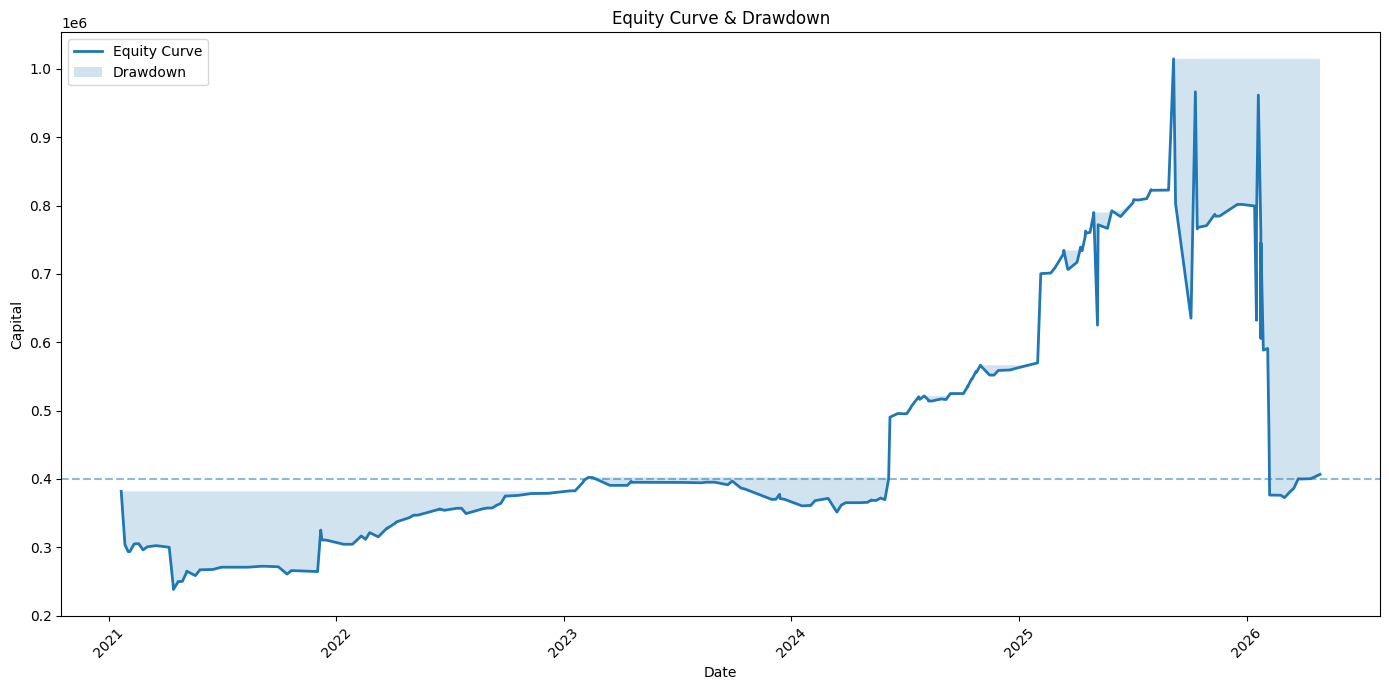

backtesting just for short straddles signals using iv rank rules.


100%|██████████| 111594/111594 [06:00<00:00, 309.97it/s]



Trades: 188
Initial Capital: 400000.00
Final Capital: 719098.51

STRATEGY PERFORMANCE SUMMARY
Initial Capital        : ₹400,000.00
Final Capital          : ₹719,098.51
Total Net Profit       : ₹319,098.51 (79.77%)
--------------------------------------------------
Total Trades           : 188
Win Rate               : 63.30%
Normalized Hit Ratio   : 67.50%
Profit Factor          : 2.08
Risk/Reward Ratio      : 1.20
Expectancy             : ₹1697.33
Sharpe Ratio           : 1.37
Calmar Ratio           : 6.97
Average Win            : ₹5,170.46
Average Loss           : ₹-4,292.55
Max Drawdown           : 11.45%



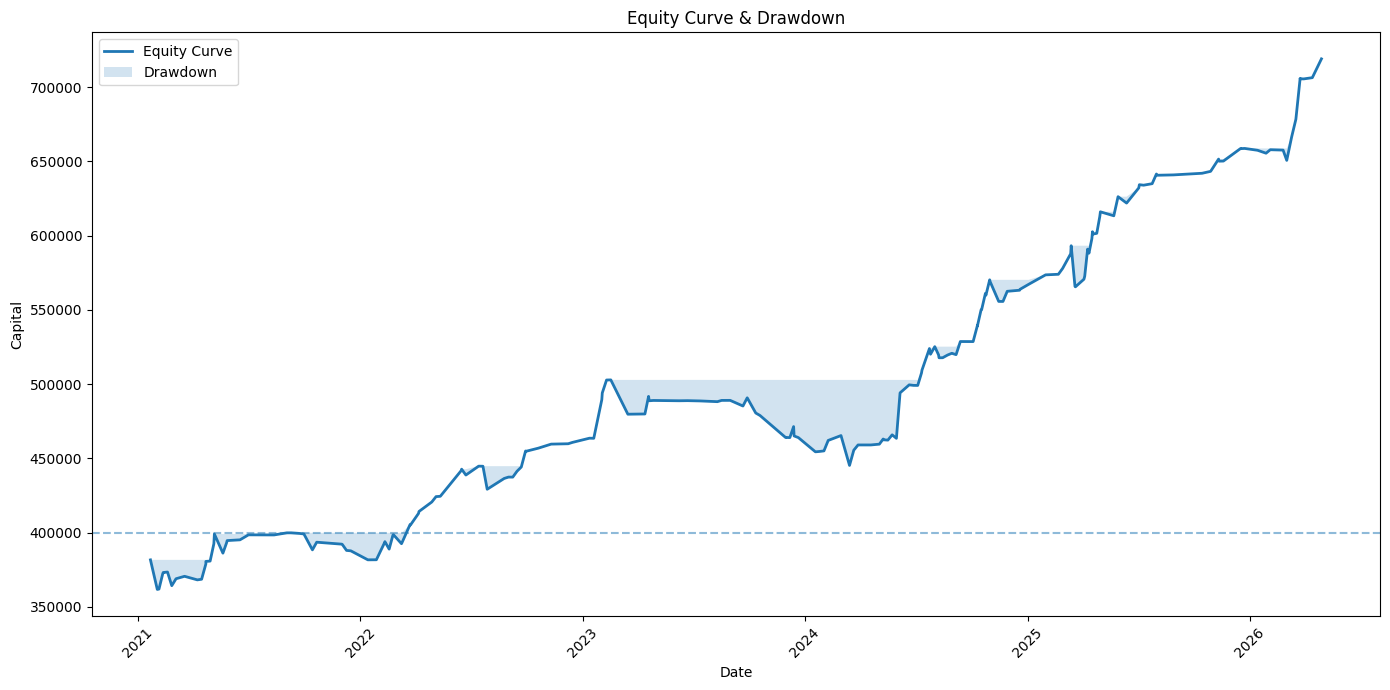

Backtesting for iv percentile


100%|██████████| 128352/128352 [07:47<00:00, 274.52it/s]



Trades: 353
Initial Capital: 400000.00
Final Capital: 417210.21

STRATEGY PERFORMANCE SUMMARY
Initial Capital        : ₹400,000.00
Final Capital          : ₹417,210.21
Total Net Profit       : ₹17,210.21 (4.30%)
--------------------------------------------------
Total Trades           : 353
Win Rate               : 59.77%
Normalized Hit Ratio   : 50.15%
Profit Factor          : 1.01
Risk/Reward Ratio      : 0.68
Expectancy             : ₹48.75
Sharpe Ratio           : 0.28
Calmar Ratio           : 0.07
Average Win            : ₹13,545.65
Average Loss           : ₹-20,006.50
Max Drawdown           : 62.93%



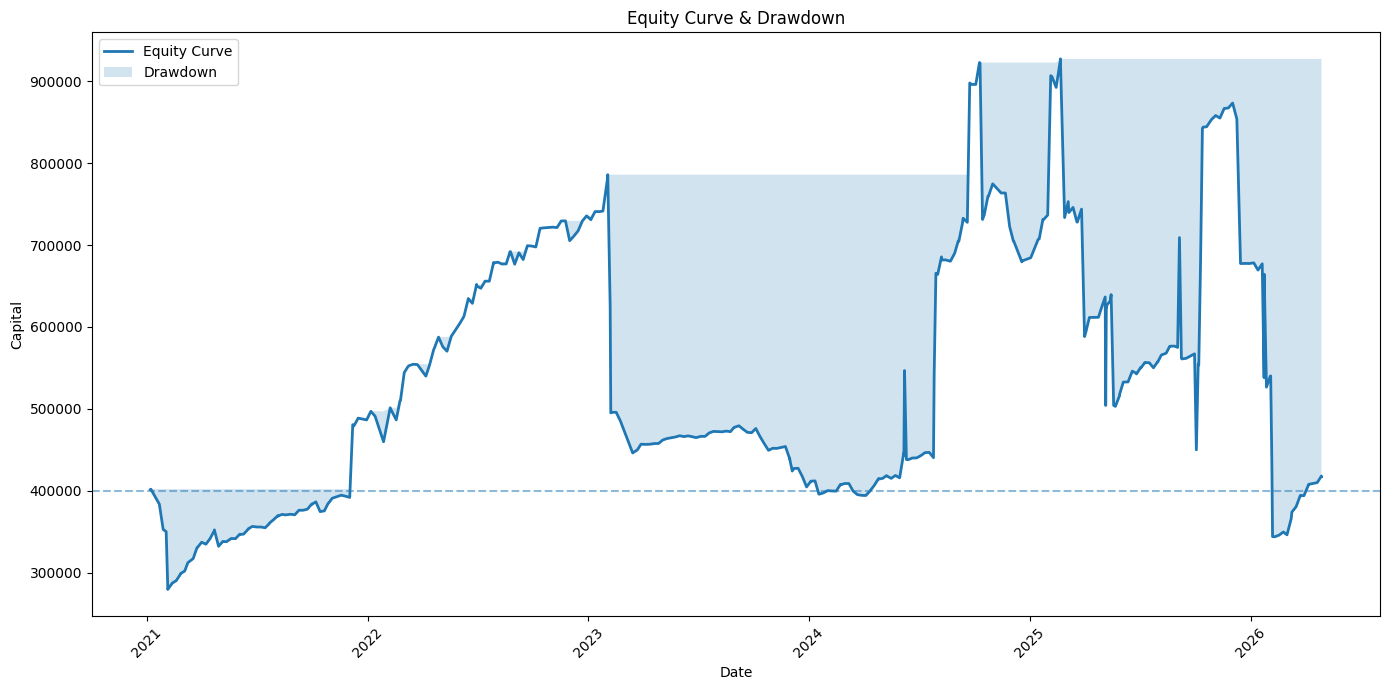

backtesting just for short straddles signals using iv percentile condition.


100%|██████████| 123696/123696 [07:45<00:00, 265.89it/s]



Trades: 325
Initial Capital: 400000.00
Final Capital: 1678283.15

STRATEGY PERFORMANCE SUMMARY
Initial Capital        : ₹400,000.00
Final Capital          : ₹1,678,283.15
Total Net Profit       : ₹1,278,283.15 (319.57%)
--------------------------------------------------
Total Trades           : 325
Win Rate               : 62.77%
Normalized Hit Ratio   : 69.35%
Profit Factor          : 2.26
Risk/Reward Ratio      : 1.34
Expectancy             : ₹3933.18
Sharpe Ratio           : 1.81
Calmar Ratio           : 13.03
Average Win            : ₹11,228.34
Average Loss           : ₹-8,366.09
Max Drawdown           : 24.52%



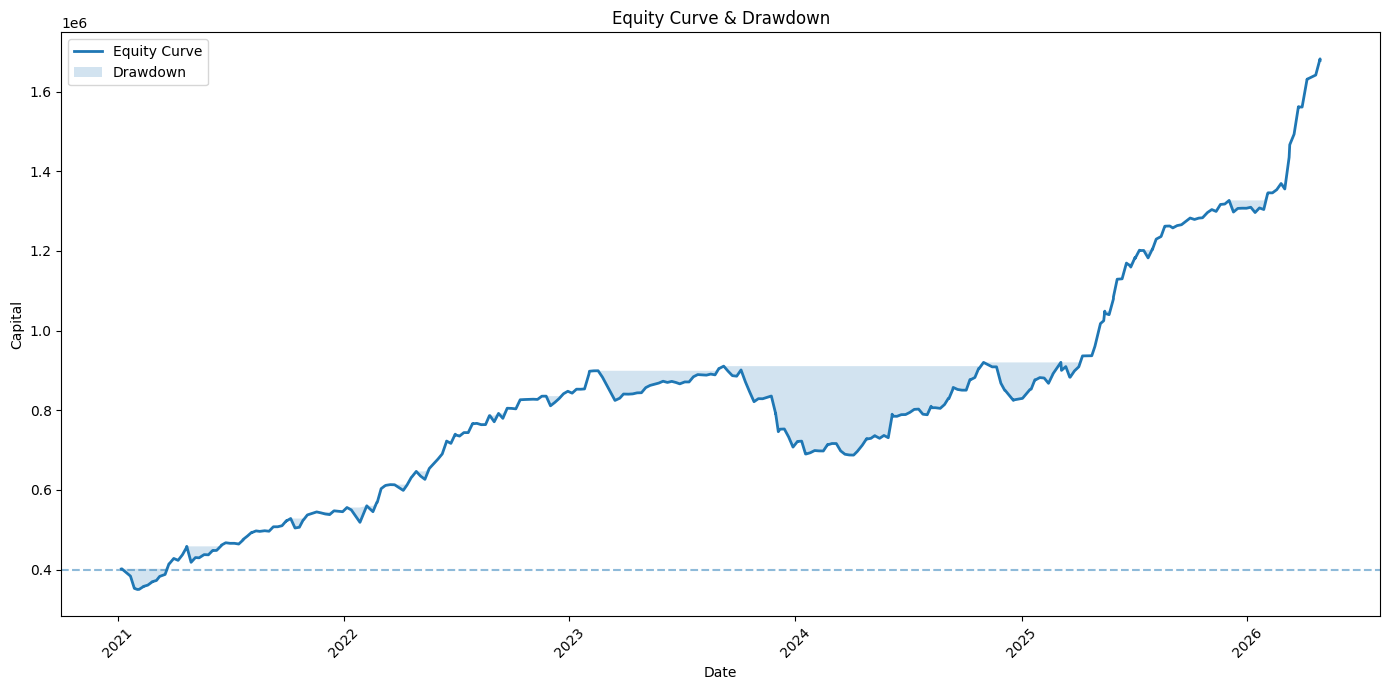

,Initial Capital,Final Capital,Total Net Profit,Total Return (%),Total Trades,Win Rate (%),Normalized Hit Ratio (%),Profit Factor,Risk/Reward Ratio,Expectancy,Sharpe Ratio,Calmar Ratio,Average Win,Average Loss,Max Drawdown (%)
0,400000.0,1678283.15,1278283.15,319.57,325,62.77,69.35,2.26,1.34,3933.18,1.81,13.03,11228.34,8366.09,24.52


In [38]:
print("Backtesting both long and  short straddles signals using iv rank rules.")
trade_df = run_straddle_backtest(
    signal_df=ivr_signal_df,
    spot_df=spot_df,
    options_path=options_path,
    initial_capital=400000,
    lot_size=65,
    strike_step=50,
    slippage_rate=0.01,
    max_capital_allocation=1.0,
    exit_timing="At 9:20 am expiry day"
)
generate_backtest_results(trade_df, initial_capital=400000.0, risk_free_rate=0.06, show_results = "Yes")


print("backtesting just for short straddles signals using iv rank rules.")
trade_df = run_straddle_backtest(
    signal_df=ivr_signal_df[ivr_signal_df['signal']==-1],
    spot_df=spot_df,
    options_path=options_path,
    initial_capital=400000,
    lot_size=65,
    strike_step=50,
    slippage_rate=0.01,
    max_capital_allocation=1.0,
    exit_timing="At 9:20 am expiry day"
)
generate_backtest_results(trade_df, initial_capital=400000.0, risk_free_rate=0.06, show_results = "Yes")


print("Backtesting for iv percentile")
trade_df = run_straddle_backtest(
    signal_df=ivp_signal_df,
    spot_df=spot_df,
    options_path=options_path,
    initial_capital=400000,
    lot_size=65,
    strike_step=50,
    slippage_rate=0.01,
    max_capital_allocation=1.0,
    exit_timing="At 9:20 am expiry day"
)
generate_backtest_results(trade_df, initial_capital=400000.0, risk_free_rate=0.06, show_results = "Yes")


print("backtesting just for short straddles signals using iv percentile condition.")
trade_df = run_straddle_backtest(
    signal_df=ivp_signal_df[ivp_signal_df['signal']==-1],
    spot_df=spot_df,
    options_path=options_path,
    initial_capital=400000,
    lot_size=65,
    strike_step=50,
    slippage_rate=0.01,
    max_capital_allocation=1.0,
    exit_timing="At 9:20 am expiry day"
)
generate_backtest_results(trade_df, initial_capital=400000.0, risk_free_rate=0.06, show_results = "Yes")

#  **Regular Backtesting for exit at One day before expiry**

Backtesting both long and  short straddles signals using iv rank rules.


100%|██████████| 114800/114800 [07:05<00:00, 270.03it/s]



Trades: 210
Initial Capital: 400000.00
Final Capital: 406644.26

STRATEGY PERFORMANCE SUMMARY
Initial Capital        : ₹400,000.00
Final Capital          : ₹406,644.26
Total Net Profit       : ₹6,644.26 (1.66%)
--------------------------------------------------
Total Trades           : 210
Win Rate               : 61.43%
Normalized Hit Ratio   : 50.08%
Profit Factor          : 1.00
Risk/Reward Ratio      : 0.63
Expectancy             : ₹31.64
Sharpe Ratio           : 0.26
Calmar Ratio           : 0.03
Average Win            : ₹15,990.86
Average Loss           : ₹-25,384.90
Max Drawdown           : 63.28%



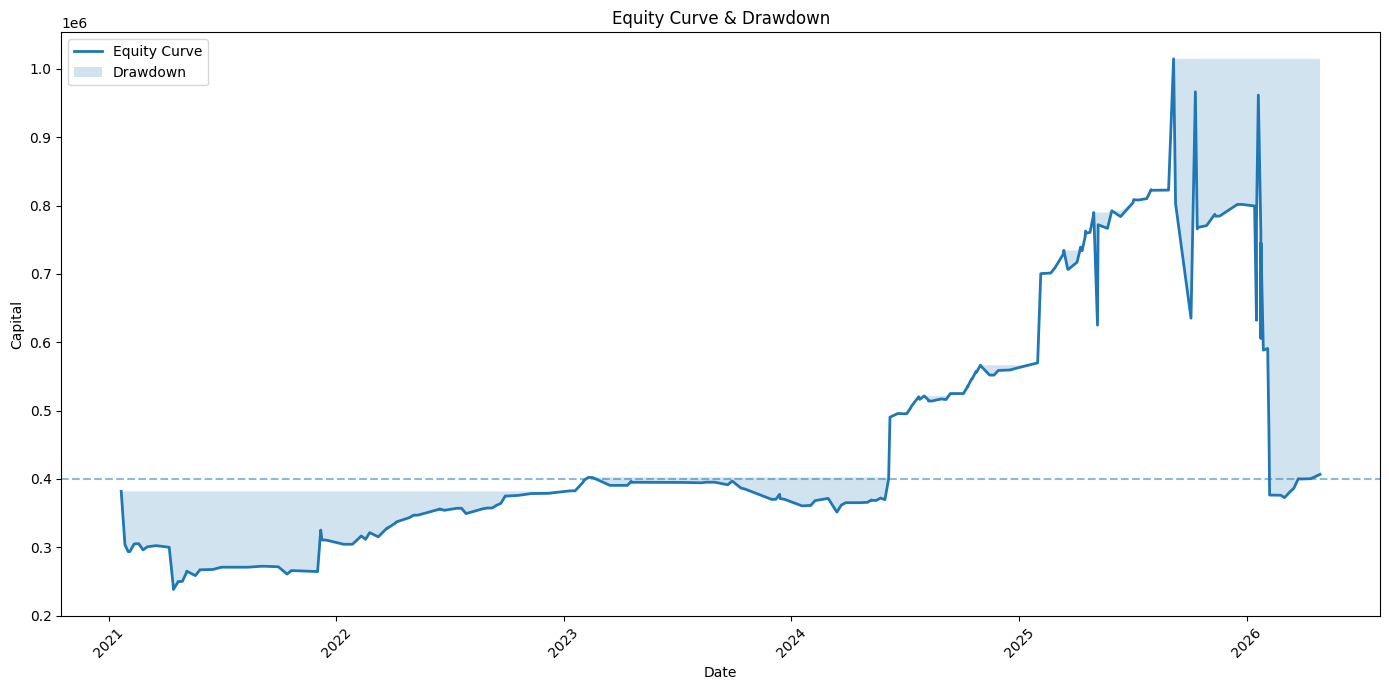

backtesting just for short straddles signals using iv rank rules.


100%|██████████| 111594/111594 [05:50<00:00, 318.04it/s]



Trades: 117
Initial Capital: 400000.00
Final Capital: 702677.68

STRATEGY PERFORMANCE SUMMARY
Initial Capital        : ₹400,000.00
Final Capital          : ₹702,677.68
Total Net Profit       : ₹302,677.68 (75.67%)
--------------------------------------------------
Total Trades           : 117
Win Rate               : 67.52%
Normalized Hit Ratio   : 66.72%
Profit Factor          : 2.00
Risk/Reward Ratio      : 0.96
Expectancy             : ₹2586.99
Sharpe Ratio           : 1.19
Calmar Ratio           : 8.74
Average Win            : ₹7,645.97
Average Loss           : ₹-7,930.37
Max Drawdown           : 8.66%



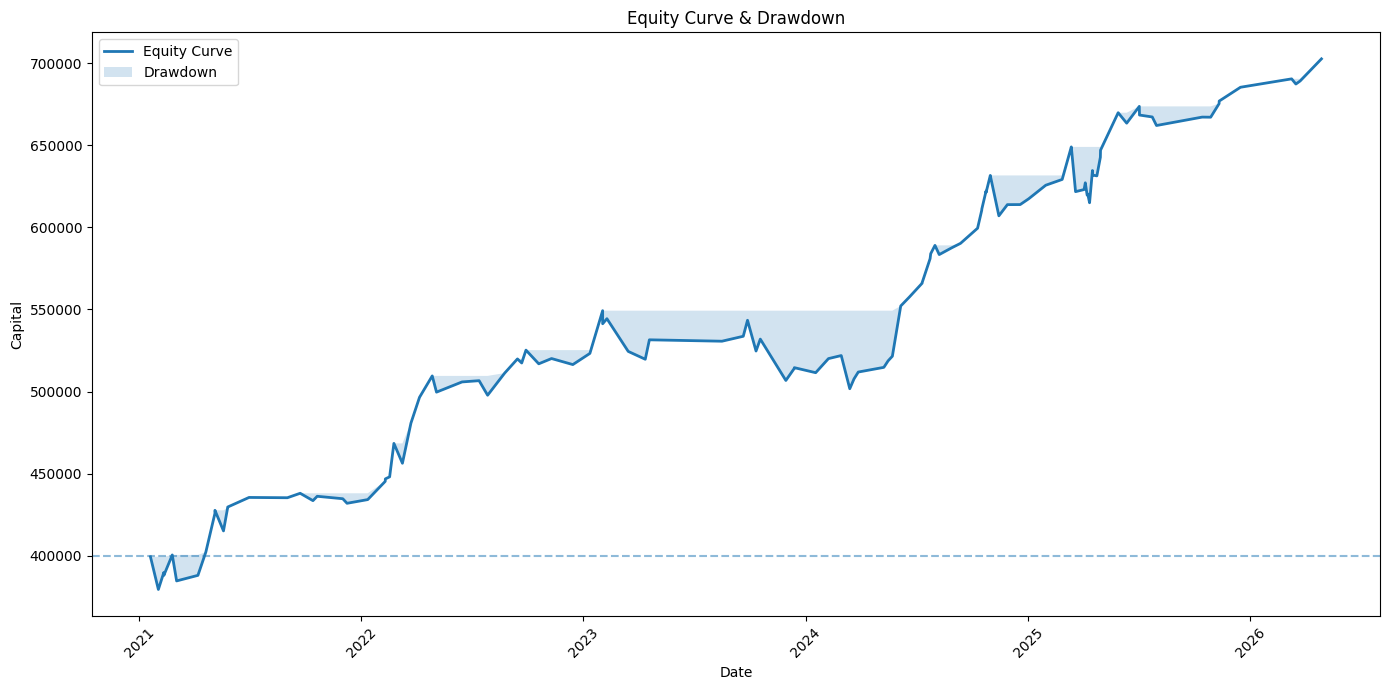

Backtesting for iv percentile


100%|██████████| 128352/128352 [07:22<00:00, 290.30it/s]



Trades: 251
Initial Capital: 400000.00
Final Capital: 461347.93

STRATEGY PERFORMANCE SUMMARY
Initial Capital        : ₹400,000.00
Final Capital          : ₹461,347.93
Total Net Profit       : ₹61,347.93 (15.34%)
--------------------------------------------------
Total Trades           : 251
Win Rate               : 64.94%
Normalized Hit Ratio   : 50.55%
Profit Factor          : 1.02
Risk/Reward Ratio      : 0.55
Expectancy             : ₹244.41
Sharpe Ratio           : 0.30
Calmar Ratio           : 0.27
Average Win            : ₹17,334.59
Average Loss           : ₹-31,411.25
Max Drawdown           : 56.12%



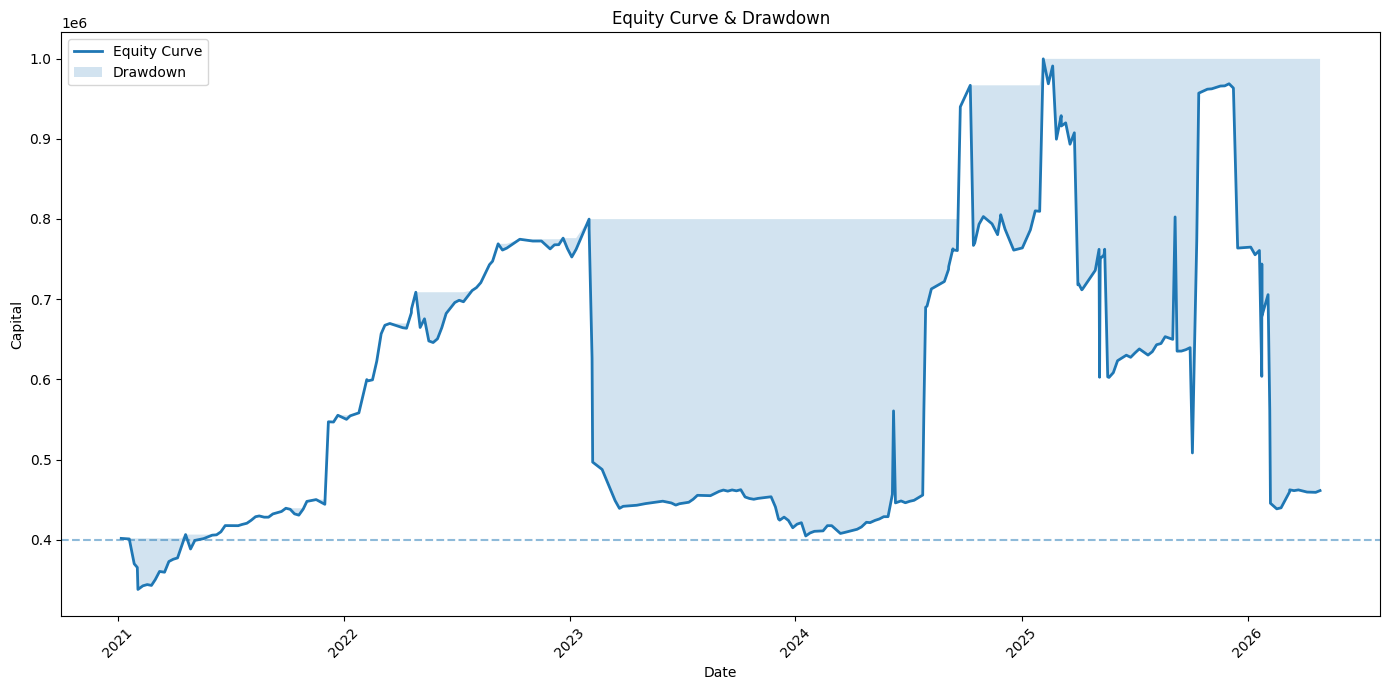

backtesting just for short straddles signals using iv percentile condition.


100%|██████████| 123696/123696 [07:29<00:00, 275.10it/s]



Trades: 224
Initial Capital: 400000.00
Final Capital: 1144114.02

STRATEGY PERFORMANCE SUMMARY
Initial Capital        : ₹400,000.00
Final Capital          : ₹1,144,114.02
Total Net Profit       : ₹744,114.02 (186.03%)
--------------------------------------------------
Total Trades           : 224
Win Rate               : 68.30%
Normalized Hit Ratio   : 67.33%
Profit Factor          : 2.06
Risk/Reward Ratio      : 0.96
Expectancy             : ₹3321.94
Sharpe Ratio           : 1.55
Calmar Ratio           : 8.43
Average Win            : ₹9,448.84
Average Loss           : ₹-9,881.11
Max Drawdown           : 22.07%



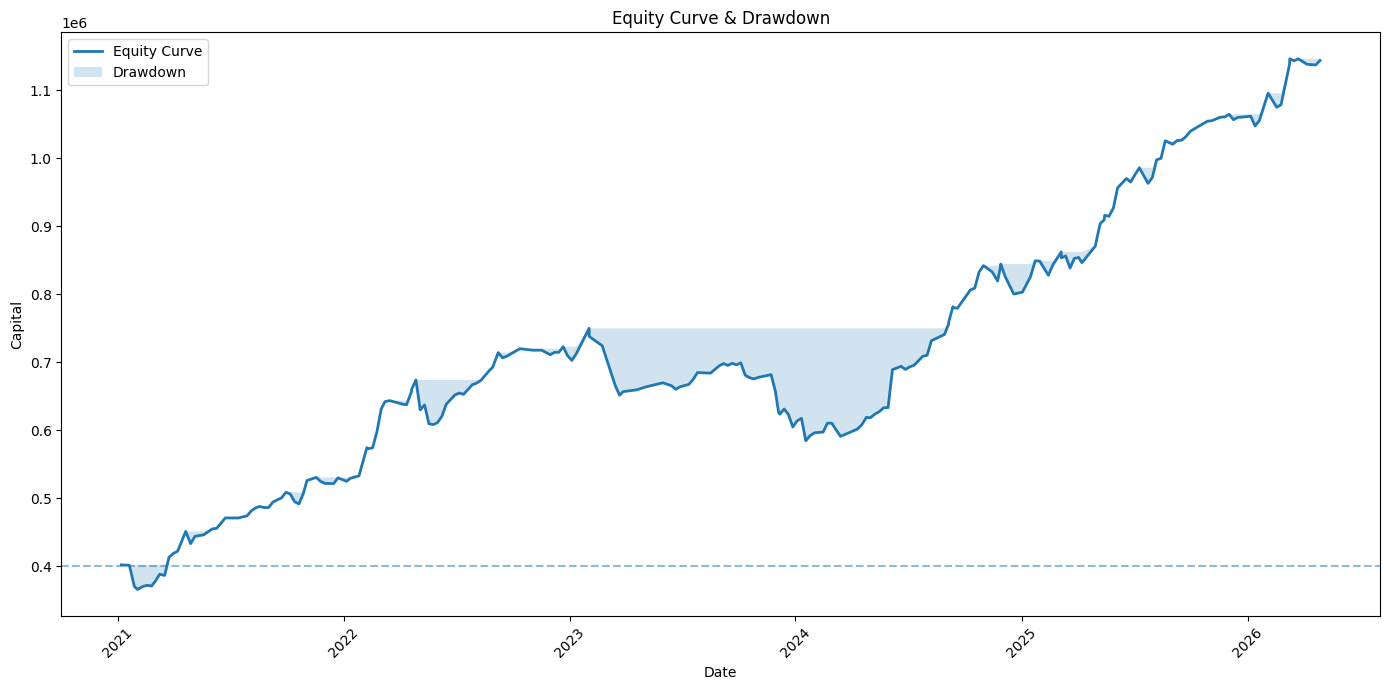

,Initial Capital,Final Capital,Total Net Profit,Total Return (%),Total Trades,Win Rate (%),Normalized Hit Ratio (%),Profit Factor,Risk/Reward Ratio,Expectancy,Sharpe Ratio,Calmar Ratio,Average Win,Average Loss,Max Drawdown (%)
0,400000.0,1144114.02,744114.02,186.03,224,68.3,67.33,2.06,0.96,3321.94,1.55,8.43,9448.84,9881.11,22.07


In [39]:
print("Backtesting both long and  short straddles signals using iv rank rules.")
trade_df = run_straddle_backtest(
    signal_df=ivr_signal_df,
    spot_df=spot_df,
    options_path=options_path,
    initial_capital=400000,
    lot_size=65,
    strike_step=50,
    slippage_rate=0.01,
    max_capital_allocation=1.0,

)
generate_backtest_results(trade_df, initial_capital=400000.0, risk_free_rate=0.06, show_results = "Yes")


print("backtesting just for short straddles signals using iv rank rules.")
trade_df = run_straddle_backtest(
    signal_df=ivr_signal_df[ivr_signal_df['signal']==-1],
    spot_df=spot_df,
    options_path=options_path,
    initial_capital=400000,
    lot_size=65,
    strike_step=50,
    slippage_rate=0.01,
    max_capital_allocation=1.0,
    exit_timing="One day before expiry day"
)
generate_backtest_results(trade_df, initial_capital=400000.0, risk_free_rate=0.06, show_results = "Yes")


print("Backtesting for iv percentile")
trade_df = run_straddle_backtest(
    signal_df=ivp_signal_df,
    spot_df=spot_df,
    options_path=options_path,
    initial_capital=400000,
    lot_size=65,
    strike_step=50,
    slippage_rate=0.01,
    max_capital_allocation=1.0,
    exit_timing="One day before expiry day"
)
generate_backtest_results(trade_df, initial_capital=400000.0, risk_free_rate=0.06, show_results = "Yes")


print("backtesting just for short straddles signals using iv percentile condition.")
trade_df = run_straddle_backtest(
    signal_df=ivp_signal_df[ivp_signal_df['signal']==-1],
    spot_df=spot_df,
    options_path=options_path,
    initial_capital=400000,
    lot_size=65,
    strike_step=50,
    slippage_rate=0.01,
    max_capital_allocation=1.0,
    exit_timing="One day before expiry day"
)
generate_backtest_results(trade_df, initial_capital=400000.0, risk_free_rate=0.06, show_results = "Yes")

# **Walk Forward Backtesting**

In [46]:
def walk_forward_backtesting(spot_iv_df, initial_capital=400000, exit_timing="At 9:20 am expiry day", decision_col = 'ivr_intraday' , signals = 'Both'):
    spot_iv_df['signal'] = 0
    years = sorted(spot_iv_df.index.year.unique().tolist())
    all_test_trade_df = pd.DataFrame()

    for year in years[:-1]:
        train_data = spot_iv_df[spot_iv_df.index.year == year]
        ivr_upper_grid = train_data[decision_col].quantile([ 0.65, 0.70, 0.75, 0.80, 0.85]).tolist()
        # ivr_lower_grid = train_data['ivr_intraday_30d'].quantile([ 0.20, 0.25, 0.30]).tolist()

        test_data = spot_iv_df[spot_iv_df.index.year == year+1]

        score_results = []
        y = None
        for x in ivr_upper_grid:
            # for y in ivr_lower_grid:

              # if signals == 'Both':
              #   train_data['signal'] = np.where((train_data['atm_iv'] >= train_data['RV']) & (train_data[decision_col] > x),-1,0)
              #   train_data['signal'] = np.where((train_data['atm_iv'] < train_data['RV']) & (train_data[decision_col] < y),1,train_data['signal'])

              # elif signals == 'Only Short':
              #   train_data['signal'] = np.where((train_data['atm_iv'] >= train_data['RV']) & (train_data[decision_col] > x),-1,0)

              train_data['signal'] = np.where((train_data['atm_iv'] >= train_data['RV']) & (train_data[decision_col] > x),-1,0)
              train_signal_df = train_data[train_data['signal'] != 0]


              trade_df = run_straddle_backtest(
                  signal_df=train_signal_df,
                  spot_df=spot_df,
                  options_path=options_path,
                  initial_capital=400000,
                  lot_size=65,
                  strike_step=50,
                  slippage_rate=0.01,
                  max_capital_allocation=1.0,
                  exit_timing=exit_timing
              )
              backtest_results = generate_backtest_results(trade_df, initial_capital=initial_capital,show_results = "No")
              score = (0.5 * backtest_results['Calmar Ratio'].iloc[0]
                  + 0.3 * backtest_results['Sharpe Ratio'].iloc[0]
                  + 0.2 * backtest_results['Profit Factor'].iloc[0])

              score_results.append({'upper_ivr_threshold': x, 'lower_ivr_threshold':y, 'score':score})

        score_df = pd.DataFrame(score_results).sort_values(by = 'score', ascending = False)
        best_upper_threshold = score_df['upper_ivr_threshold'].iloc[0]
        best_lower_threshold = score_df['lower_ivr_threshold'].iloc[0]

        print(f'From the year {year}, best_upper_threshold = {best_upper_threshold} and best_lower_threshold = {best_lower_threshold}')


        # testing
        test_data['signal'] = np.where((test_data['atm_iv'] >= test_data['RV']) & (test_data[decision_col] > best_upper_threshold),-1,0)
        # test_data['signal'] = np.where((test_data['atm_iv'] < test_data['RV']) & (test_data['ivr_intraday_30d'] < best_lower_threshold),1,test_data['signal'])
        test_signal_df = test_data[test_data['signal'] != 0]

        trade_df = run_straddle_backtest(
            signal_df=test_signal_df,
            spot_df=spot_df,
            options_path=options_path,
            initial_capital=400000
                            if all_test_trade_df is None or all_test_trade_df.empty
                            else all_test_trade_df["capital_after_trade"].iloc[-1] ,
            lot_size=65,
            strike_step=50,
            slippage_rate=0.01,
            max_capital_allocation=1.0,
            exit_timing=exit_timing
        )

        all_test_trade_df = pd.concat([all_test_trade_df, trade_df],ignore_index=True)

    backtest_results = generate_backtest_results(all_test_trade_df, initial_capital=initial_capital,show_results = "Yes")


100%|██████████| 29642/29642 [00:46<00:00, 642.55it/s]



Trades: 58
Initial Capital: 400000.00
Final Capital: 801514.85


100%|██████████| 25370/25370 [00:41<00:00, 616.53it/s]



Trades: 50
Initial Capital: 400000.00
Final Capital: 804674.63


100%|██████████| 21117/21117 [00:39<00:00, 536.39it/s]


...


Trades: 33
Initial Capital: 400000.00
Final Capital: 472247.04


100%|██████████| 13516/13516 [00:53<00:00, 251.47it/s]



Trades: 28
Initial Capital: 400000.00
Final Capital: 465571.96
From the year 2025, best_upper_threshold = 0.1304613438947559 and best_lower_threshold = None


100%|██████████| 10116/10116 [00:36<00:00, 279.71it/s]



Trades: 17
Initial Capital: 671966.00
Final Capital: 760270.23

STRATEGY PERFORMANCE SUMMARY
Initial Capital        : ₹400,000.00
Final Capital          : ₹760,270.23
Total Net Profit       : ₹360,270.23 (90.07%)
--------------------------------------------------
Total Trades           : 220
Win Rate               : 60.91%
Normalized Hit Ratio   : 63.48%
Profit Factor          : 1.74
Risk/Reward Ratio      : 1.12
Expectancy             : ₹1637.59
Sharpe Ratio           : 1.15
Calmar Ratio           : 4.42
Average Win            : ₹6,329.24
Average Loss           : ₹-5,672.65
Max Drawdown           : 20.37%



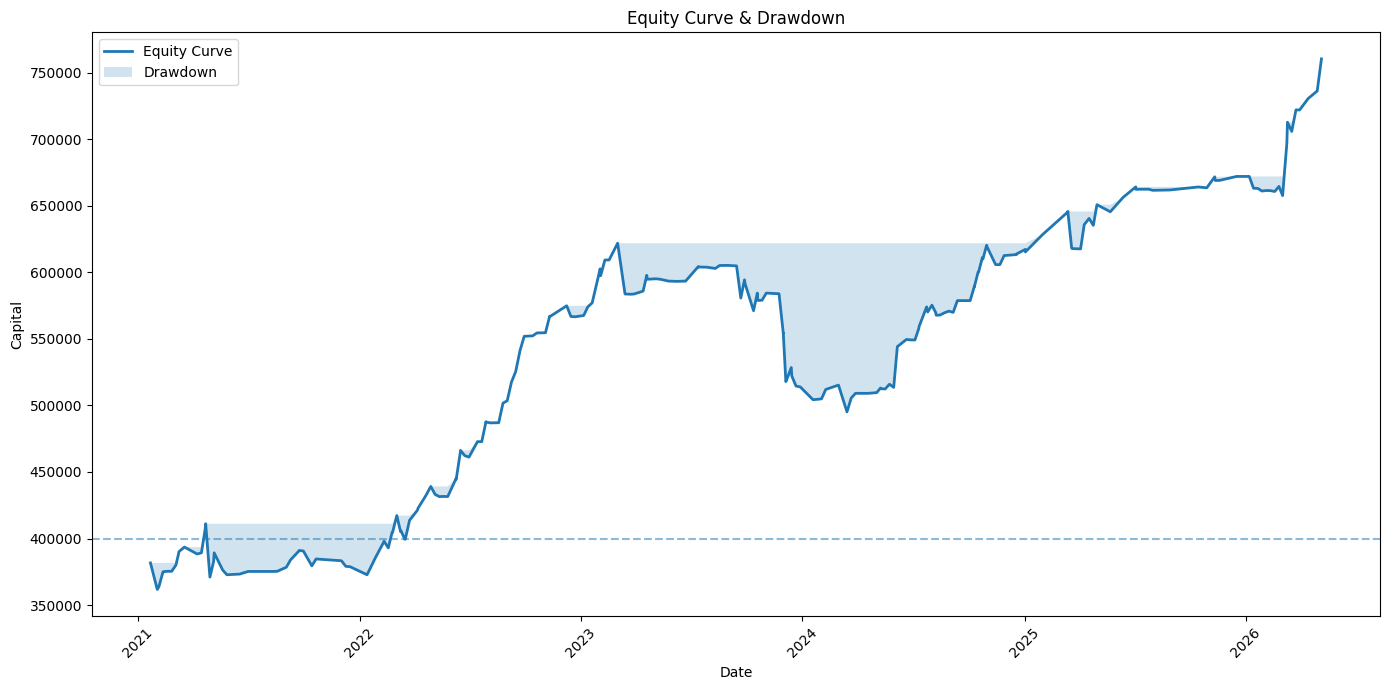

In [41]:
walk_forward_backtesting(ivr_df, initial_capital=400000, exit_timing="At 9:20 am expiry day", decision_col = 'ivr_intraday' , signals = 'Only Short')

100%|██████████| 29791/29791 [00:50<00:00, 595.34it/s]



Trades: 66
Initial Capital: 400000.00
Final Capital: 726454.19


100%|██████████| 25549/25549 [00:47<00:00, 542.60it/s]



Trades: 63
Initial Capital: 400000.00
Final Capital: 639385.18


100%|██████████| 21235/21235 [00:47<00:00, 447.92it/s]


...


Trades: 61
Initial Capital: 400000.00
Final Capital: 544237.93


100%|██████████| 13517/13517 [01:36<00:00, 140.57it/s]



Trades: 49
Initial Capital: 400000.00
Final Capital: 488323.53
From the year 2025, best_upper_threshold = 0.6266666666666667 and best_lower_threshold = None


100%|██████████| 10494/10494 [00:35<00:00, 292.17it/s]



Trades: 23
Initial Capital: 1272456.94
Final Capital: 1726091.55

STRATEGY PERFORMANCE SUMMARY
Initial Capital        : ₹400,000.00
Final Capital          : ₹1,726,091.55
Total Net Profit       : ₹1,326,091.55 (331.52%)
--------------------------------------------------
Total Trades           : 315
Win Rate               : 63.17%
Normalized Hit Ratio   : 67.60%
Profit Factor          : 2.09
Risk/Reward Ratio      : 1.22
Expectancy             : ₹4209.81
Sharpe Ratio           : 1.82
Calmar Ratio           : 12.44
Average Win            : ₹12,796.92
Average Loss           : ₹-10,521.51
Max Drawdown           : 26.65%



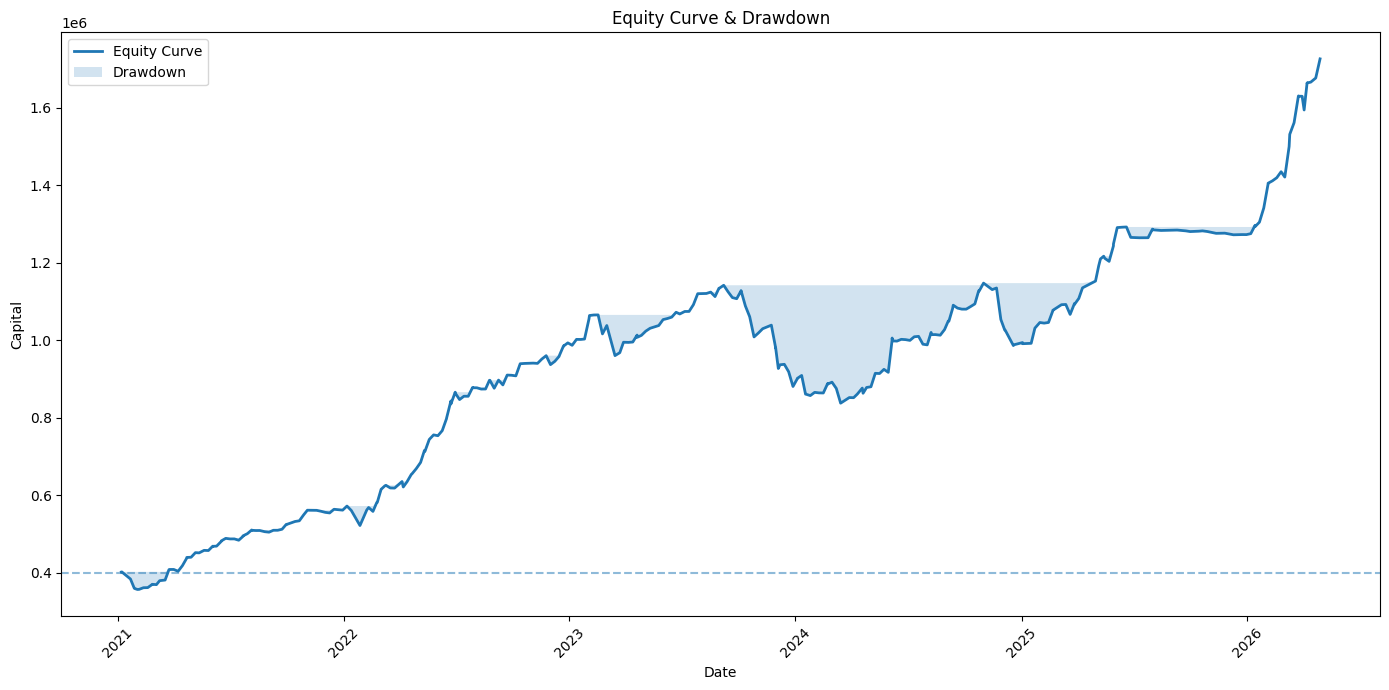

In [42]:
walk_forward_backtesting(ivr_df, initial_capital=400000, exit_timing="At 9:20 am expiry day", decision_col = 'iv_percentile_intraday' , signals = 'Only Short')

100%|██████████| 29642/29642 [00:44<00:00, 664.80it/s]



Trades: 32
Initial Capital: 400000.00
Final Capital: 651633.13


100%|██████████| 25370/25370 [00:40<00:00, 623.92it/s]



Trades: 28
Initial Capital: 400000.00
Final Capital: 642842.83


100%|██████████| 21117/21117 [00:38<00:00, 543.54it/s]


...


Trades: 25
Initial Capital: 400000.00
Final Capital: 432453.29


100%|██████████| 13516/13516 [00:55<00:00, 244.78it/s]



Trades: 21
Initial Capital: 400000.00
Final Capital: 438237.88
From the year 2025, best_upper_threshold = 0.1304613438947559 and best_lower_threshold = None


100%|██████████| 10116/10116 [00:38<00:00, 264.24it/s]



Trades: 11
Initial Capital: 606465.65
Final Capital: 696753.34

STRATEGY PERFORMANCE SUMMARY
Initial Capital        : ₹400,000.00
Final Capital          : ₹696,753.34
Total Net Profit       : ₹296,753.34 (74.19%)
--------------------------------------------------
Total Trades           : 134
Win Rate               : 70.15%
Normalized Hit Ratio   : 64.81%
Profit Factor          : 1.84
Risk/Reward Ratio      : 0.78
Expectancy             : ₹2214.58
Sharpe Ratio           : 1.06
Calmar Ratio           : 6.09
Average Win            : ₹6,907.89
Average Loss           : ₹-8,814.70
Max Drawdown           : 12.18%



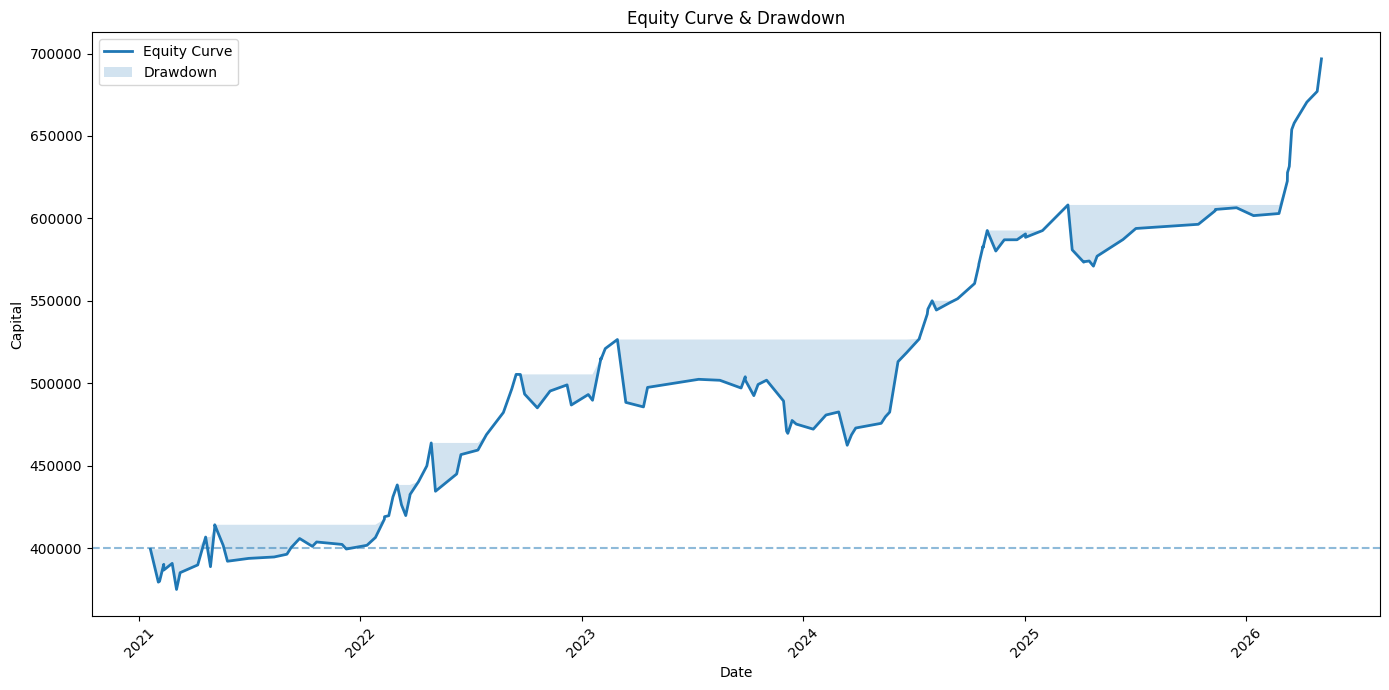

In [43]:
walk_forward_backtesting(ivr_df, initial_capital=400000, exit_timing="One day before expiry day", decision_col = 'ivr_intraday'  , signals = 'Only Short')

100%|██████████| 29791/29791 [00:48<00:00, 615.61it/s]



Trades: 45
Initial Capital: 400000.00
Final Capital: 747026.55


100%|██████████| 25549/25549 [00:49<00:00, 521.03it/s]



Trades: 39
Initial Capital: 400000.00
Final Capital: 694814.60


100%|██████████| 21235/21235 [00:46<00:00, 452.54it/s]


...


Trades: 35
Initial Capital: 400000.00
Final Capital: 498735.12


100%|██████████| 13517/13517 [01:38<00:00, 137.68it/s]



Trades: 19
Initial Capital: 400000.00
Final Capital: 461001.41
From the year 2025, best_upper_threshold = 0.6266666666666667 and best_lower_threshold = None


100%|██████████| 10494/10494 [00:34<00:00, 306.47it/s]



Trades: 16
Initial Capital: 1013994.42
Final Capital: 1141786.61

STRATEGY PERFORMANCE SUMMARY
Initial Capital        : ₹400,000.00
Final Capital          : ₹1,141,786.61
Total Net Profit       : ₹741,786.61 (185.45%)
--------------------------------------------------
Total Trades           : 221
Win Rate               : 68.33%
Normalized Hit Ratio   : 66.92%
Profit Factor          : 2.02
Risk/Reward Ratio      : 0.94
Expectancy             : ₹3356.50
Sharpe Ratio           : 1.58
Calmar Ratio           : 8.24
Average Win            : ₹9,715.25
Average Loss           : ₹-10,360.22
Max Drawdown           : 22.50%



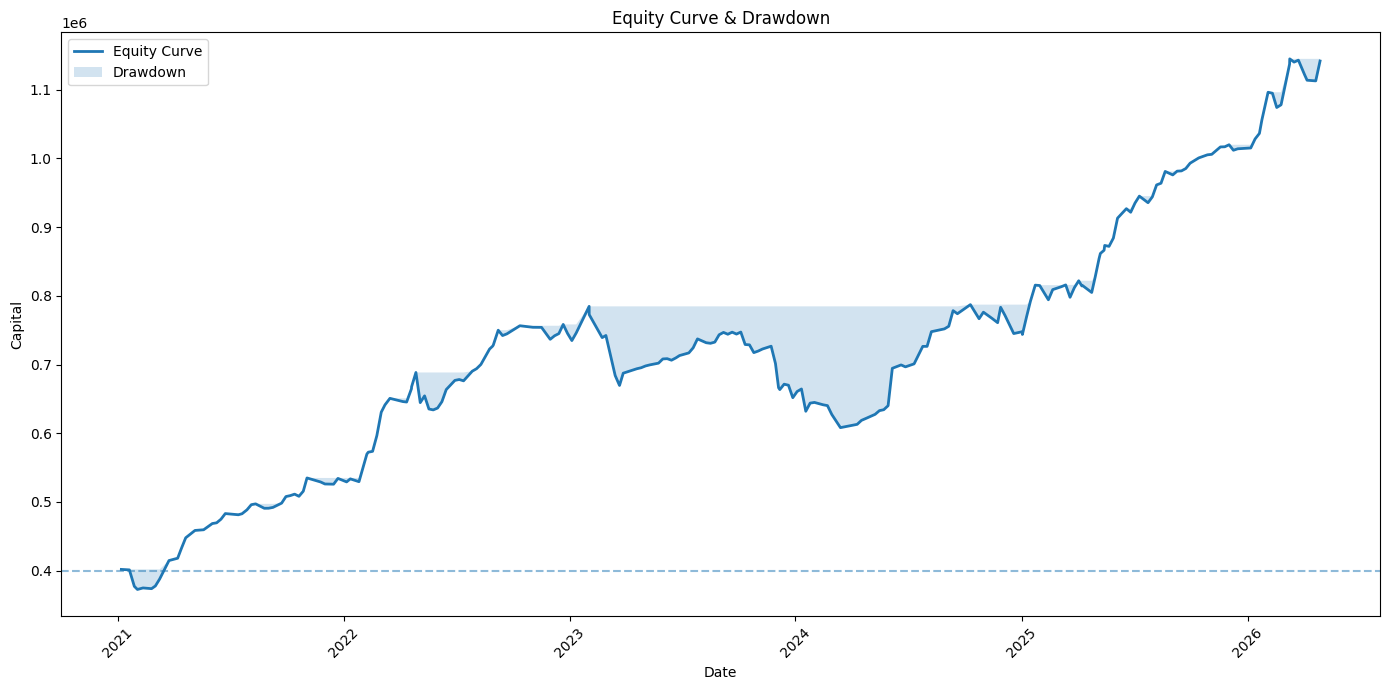

In [44]:
walk_forward_backtesting(ivr_df, initial_capital=400000, exit_timing="One day before expiry day", decision_col = 'iv_percentile_intraday' , signals = 'Only Short')